## 2. EDA
### 2.1 Подготовка

In [1]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import re

In [2]:
# отключаем экспоненциальное отображение чисел в pandas и numpy и делаем удобное форматирование
def smart_float(x):
    if pd.isnull(x):
        return ""
    elif float(x).is_integer():
        return '{:.0f}'.format(x) # отображаем целые числа без нулевой десятичной части
    else:
        return '{:.6f}'.format(x).rstrip('0').rstrip('.') # отображаем числа с плавающей запятой без лишних нулей

pd.set_option('display.float_format', smart_float)
np.set_printoptions(suppress=True)
# Снимаем ограничение на число отображаемых столбцов в pandas
pd.set_option('display.max_columns', None)      # показывать все столбцы
pd.set_option('display.width', None)            # не ограничивать ширину вывода
pd.set_option('display.max_colwidth', None)     # не ограничивать ширину столбца

In [3]:
# Загружаем подготовленный датасет
data = pd.read_parquet("fraud.parquet")
# Некоторые категориальные признаки не восстановились, делаем вручную.
data["Merchant_Zip"] = data["Merchant_Zip"].astype("category")
data["User_Zip"] = data["User_Zip"].astype("category")
data.head()


,User,Card,Timestamp,Amount,Use_Chip,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,MCC,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,User_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year
0,0,0,2002-09-01 06:21:00,134.089996,Swipe Transaction,69374,La Verne,CA,91750,5300,None,No,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,NaN,La Verne,CA,91750,34.150002,-117.760002,29278,59696,127613,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295,2002-09-01,2008
1,0,0,2002-09-01 06:42:00,38.48,Swipe Transaction,46284,Monterey Park,CA,91754,5411,None,No,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,NaN,La Verne,CA,91750,34.150002,-117.760002,29278,59696,127613,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295,2002-09-01,2008
2,0,0,2002-09-02 06:22:00,120.339996,Swipe Transaction,46284,Monterey Park,CA,91754,5411,None,No,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,NaN,La Verne,CA,91750,34.150002,-117.760002,29278,59696,127613,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295,2002-09-01,2008
3,0,0,2002-09-02 17:45:00,128.949997,Swipe Transaction,68751,Monterey Park,CA,91754,5651,None,No,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,NaN,La Verne,CA,91750,34.150002,-117.760002,29278,59696,127613,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295,2002-09-01,2008
4,0,0,2002-09-03 06:23:00,104.709999,Swipe Transaction,81833,La Verne,CA,91750,5912,None,No,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,NaN,La Verne,CA,91750,34.150002,-117.760002,29278,59696,127613,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295,2002-09-01,2008


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24386900 entries, 0 to 24386899
Data columns (total 41 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   User                       int16         
 1   Card                       int8          
 2   Timestamp                  datetime64[ns]
 3   Amount                     float32       
 4   Use_Chip                   category      
 5   Merchant_ID                int32         
 6   Merchant_City              category      
 7   Merchant_State             category      
 8   Merchant_Zip               category      
 9   MCC                        int64         
 10  Errors                     object        
 11  Fraud                      object        
 12  Person                     object        
 13  Current_Age                int8          
 14  Retirement_Age             int8          
 15  Birth_Year                 int16         
 16  Birth_Month                int8   

## 2.2 Заполнение пропусков

In [5]:
# Проверям наличие пропусков
print(data.isnull().sum())

User                                0
Card                                0
Timestamp                           0
Amount                              0
Use_Chip                            0
Merchant_ID                         0
Merchant_City                       0
Merchant_State                2720821
Merchant_Zip                  2878135
MCC                                 0
Errors                       23998469
Fraud                               0
Person                              0
Current_Age                         0
Retirement_Age                      0
Birth_Year                          0
Birth_Month                         0
Gender                              0
User_Address                        0
User_Apartment               17762699
User_City                           0
User_State                          0
User_Zip                            0
User_Latitude                       0
User_Longitude                      0
Per_Capita_Income_Zipcode           0
Yearly_Incom

In [6]:
# Посмотрим примеры строк без названия страны
data[data["Merchant_State"].isna()].sample(10)

,User,Card,Timestamp,Amount,Use_Chip,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,MCC,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,User_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year
15782094,1281,0,2014-12-20 05:51:00,34.419998,Online Transaction,16798,ONLINE,NaN,NaN,4121,None,No,Davian Ortiz,59,54,1960,9,1,350 Jefferson Boulevard,NaN,Inglewood,CA,90302,33.970001,-118.349998,18476,28245,13411,669,1,0,Mastercard,Debit,5755010791716629,2022-04-30,497,1,2,6090,2009-11-01,2011
14904972,1223,2,2008-03-19 07:17:00,56.25,Online Transaction,39021,ONLINE,NaN,NaN,4784,None,No,Colson Nguyen,52,68,1967,7,1,9028 Valley Stream Avenue,NaN,Albany,NY,12203,42.66,-73.790001,27005,55059,162462,735,3,2,Mastercard,Debit,5514653687166060,2024-08-31,70,1,1,28790,2001-03-01,2009
21763163,1777,0,2009-05-11 01:17:00,17.66,Online Transaction,18563,ONLINE,NaN,NaN,4121,None,No,Deborah Clark,60,67,1959,10,0,8179 Valley Stream Drive,NaN,Holly,MI,48442,42.790001,-83.620003,22680,46244,108449,814,5,0,Mastercard,Credit,5124181575265453,2020-02-29,308,1,2,10800,2007-04-01,2010
16563232,1342,0,2006-09-12 09:35:00,88.07,Online Transaction,73186,ONLINE,NaN,NaN,4814,None,No,Marcelo Gao,47,72,1972,11,1,37845 Main Street,NaN,Keller,TX,76248,32.93,-97.220001,0,3,5,750,2,0,Visa,Credit,4696206742094892,2021-09-30,52,1,2,0,2000-04-01,2011
19770006,1603,2,2006-02-21 13:07:00,13.77,Online Transaction,65108,ONLINE,NaN,NaN,4899,None,No,Westin Jackson,42,67,1977,8,1,9387 Lincoln Boulevard,5,Clever,MO,65631,37.02,-93.470001,17222,35119,57463,850,3,2,Discover,Credit,6416258939868696,2022-05-31,101,0,1,11400,2003-03-01,2014
3156479,262,1,2018-06-17 08:38:00,32.200001,Online Transaction,88998,ONLINE,NaN,NaN,4784,None,No,Jaxon Cook,38,64,1981,5,1,215 Ocean View Drive,NaN,Olympia,WA,98516,47.110001,-122.760002,24044,49023,66148,583,5,1,Visa,Debit,4275115874708969,2023-09-30,740,1,2,32075,2004-07-01,2010
22352466,1825,1,2009-04-15 17:11:00,30.84,Online Transaction,16798,ONLINE,NaN,NaN,4121,None,No,Simeon Flores,47,67,1972,5,1,166 12th Street,NaN,Annandale,VA,22003,38.830002,-77.209999,30622,62432,95799,741,5,1,Mastercard,Debit (Prepaid),5863932577604198,2023-05-31,815,1,1,61,2004-10-01,2012
57260,2,1,2017-08-09 09:39:00,51.150002,Online Transaction,15143,ONLINE,NaN,NaN,4784,None,No,Saanvi Lee,81,67,1938,11,0,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.889999,22681,33483,196,698,5,1,Mastercard,Debit,5804499644308599,2023-07-31,258,0,2,27480,2002-03-01,2008
8005851,680,2,2017-03-03 14:18:00,44.09,Online Transaction,22696,ONLINE,NaN,NaN,5192,None,No,Sadie Braun,81,64,1938,9,0,678 Park Drive,NaN,Miami,FL,33179,25.77,-80.199997,19386,23217,2559,616,3,2,Mastercard,Debit,5079874786244954,2022-06-30,200,1,2,1976,2000-10-01,2008
23634000,1930,2,2011-12-27 16:48:00,28.42,Online Transaction,16798,ONLINE,NaN,NaN,4121,None,No,Lennon Richardson,54,70,1965,11,1,6831 Valley Boulevard,NaN,San Rafael,CA,94901,37.970001,-122.5,30819,62837,86171,850,3,2,Mastercard,Debit,5469185883238396,2024-02-29,610,1,2,15422,1999-12-01,2009


In [7]:
# Теория - пропуск в названии страны соответствует он-лайн транзакциям. Проверим эту гипотезу.
pd.crosstab(
    data["Merchant_State"].isna(),
    data["Use_Chip"]
)

Use_Chip,Chip Transaction,Online Transaction,Swipe Transaction
Merchant_State,,,
False,6279997,0,15386082
True,0,2720821,0


In [8]:
# Гипотеза верна - для он-лайн транзакций не указана страна. Это плохо, так-как уровень мошенничества с он-лайн транзакциями в разных
# странах может отличаться. Но мы не можем ничего с этим поделать, так-как это изначальная особенность данных и у нас нет способа ей устранить.
# Поэтому просто заполним пропуски специальной категорией "Online".
data["Merchant_State"] = (
    data["Merchant_State"]
    .cat.add_categories("ONLINE")
    .fillna("ONLINE")
)

In [9]:
# Посмотрим примеры отсутсвтия ZIP-кода мерчанта
data[data["Merchant_Zip"].isna()].sample(10)

,User,Card,Timestamp,Amount,Use_Chip,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,MCC,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,User_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year
17827383,1438,1,2007-10-16 23:27:00,-166,Online Transaction,13348,ONLINE,ONLINE,NaN,4722,None,No,Camille Lopez,37,68,1982,5,0,365 Ocean Lane,NaN,Holden,MA,1520,42.349998,-71.849998,31514,64252,92973,802,2,1,Mastercard,Debit,5034696278823231,2020-11-30,154,1,1,43122,2002-10-01,2011
22836518,1869,1,2016-09-11 15:48:00,326,Online Transaction,51300,ONLINE,ONLINE,NaN,3359,None,Yes,Tinley Watson,39,66,1980,11,0,364 12th Drive,2,Tacoma,WA,98445,47.130001,-122.400002,20345,41483,64098,721,2,1,Discover,Credit,6737538441360610,2024-08-31,595,1,1,10600,2003-02-01,2007
4680964,396,1,2011-01-15 16:13:00,60.130001,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,None,No,Simeon Cruz,47,75,1972,10,1,130 Lincoln Drive,159,Nashport,OH,43830,40.040001,-82.120003,21156,43133,44263,693,3,1,Amex,Credit,357731604070533,2020-05-31,270,1,1,13400,1999-10-01,2012
4985420,421,2,2011-03-25 20:32:00,20.16,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,None,No,Lawson Gray,49,70,1970,3,1,2248 Third Avenue,918,Chattanooga,TN,37416,35.060001,-85.25,18658,38041,27813,782,4,2,Mastercard,Debit,5312379293764300,2022-06-30,244,0,2,17564,2010-12-01,2010
22100472,1799,0,2011-02-23 08:36:00,73.029999,Swipe Transaction,51300,Tokyo,Japan,NaN,3359,None,No,Melvin Brown,73,67,1946,3,1,2834 West Street,NaN,Mobile,AL,36695,30.68,-88.040001,25381,48060,17440,581,3,0,Mastercard,Debit,5346665102858338,2024-01-31,734,1,1,4534,2009-01-01,2010
13161564,1080,0,2013-12-16 06:20:00,11.43,Online Transaction,50404,ONLINE,ONLINE,NaN,4784,None,No,Rowan Rodriguez,63,65,1956,12,0,4461 Hill Street,NaN,Merritt Island,FL,32952,28.32,-80.68,26339,53702,85160,606,1,0,Mastercard,Debit,5412731781518758,2018-05-31,599,1,2,12047,2000-04-01,2008
1207352,96,0,2013-03-26 23:55:00,30.700001,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,None,No,Kase Nguyen,54,69,1965,9,1,3683 Fifth Street,7760,Mount Holly,NC,28120,35.299999,-81.029999,22487,45852,114746,615,2,0,Visa,Debit,4439832703761219,2020-08-31,424,1,2,2292,2009-10-01,2015
11906387,984,1,2019-07-29 15:43:00,13.46,Online Transaction,15143,ONLINE,ONLINE,NaN,4784,None,No,Lilly James,29,67,1990,10,0,645 Tenth Boulevard,NaN,El Cajon,CA,92021,32.84,-116.879997,20673,42150,39663,750,3,1,Mastercard,Debit,5892951431288814,2021-11-30,447,1,1,20619,2018-07-01,2018
20479058,1671,0,2007-08-01 07:11:00,57.09,Online Transaction,50404,ONLINE,ONLINE,NaN,4784,None,No,Chris Hill,36,64,1983,11,1,2352 Bayview Boulevard,10,Orlando,FL,32804,28.5,-81.370003,33078,67444,93513,850,1,0,Amex,Credit,352397360356465,2022-08-31,465,1,2,18000,2002-06-01,2011
38477,2,1,2003-04-07 14:54:00,40.970001,Online Transaction,15143,ONLINE,ONLINE,NaN,4784,None,No,Saanvi Lee,81,67,1938,11,0,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.889999,22681,33483,196,698,5,1,Mastercard,Debit,5804499644308599,2023-07-31,258,0,2,27480,2002-03-01,2008


In [10]:
# Теория - ZIP-кодов нет у мерчантов он-лайн и у мерчантов определённых стран. Проверим эти гипотезы.
pd.crosstab(
    data["Merchant_Zip"].isna(),
    data["Merchant_State"]
)

Merchant_State,AA,AK,AL,AR,AZ,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Aruba,Australia,Austria,Azerbaijan,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bosnia and Herzegovina,Botswana,Brazil,Brunei,Bulgaria,Burkina Faso,CA,CO,CT,Cabo Verde,Cambodia,Cameroon,Canada,Central African Republic,Chile,China,Colombia,Comoros,Costa Rica,Cote d'Ivoire,Croatia,Cyprus,Czech Republic,DC,DE,Democratic Republic of the Congo,Denmark,Djibouti,Dominica,Dominican Republic,East Timor (Timor-Leste),Ecuador,Egypt,El Salvador,Equatorial Guinea,Eritrea,Estonia,Ethiopia,FL,Fiji,Finland,France,GA,Gabon,Georgia,Germany,Ghana,Greece,Guatemala,Guinea,Guyana,HI,Haiti,Honduras,Hong Kong,Hungary,IA,ID,IL,IN,Iceland,India,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,KS,KY,Kenya,Kiribati,Kosovo,Kuwait,Kyrgyzstan,LA,Latvia,Lebanon,Liberia,Liechtenstein,Lithuania,Luxembourg,MA,MD,ME,MI,MN,MO,MS,MT,Macedonia,Malawi,Malaysia,Maldives,Mali,Malta,Marshall Islands,Mexico,Micronesia,Moldova,Monaco,Mongolia,Montenegro,Morocco,Mozambique,Myanmar (Burma),NC,ND,NE,NH,NJ,NM,NV,NY,Nauru,Netherlands,New Zealand,Nicaragua,Niger,Nigeria,Norway,OH,OK,OR,Oman,PA,Pakistan,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,RI,Republic of the Congo,Romania,Russia,SC,SD,Saint Lucia,Saint Vincent and the Grenadines,Samoa,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovakia,Slovenia,Solomon Islands,Somalia,South Africa,South Korea,South Sudan,Spain,Sri Lanka,Sudan,Suriname,Swaziland,Sweden,Switzerland,Syria,TN,TX,Taiwan,Tanzania,Thailand,The Bahamas,Togo,Tonga,Trinidad and Tobago,Tunisia,Turkey,Tuvalu,UT,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,VA,VT,Vanuatu,Vatican City,Venezuela,Vietnam,WA,WI,WV,WY,Yemen,Zambia,Zimbabwe,ONLINE
Merchant_Zip,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
False,12,18301,338628,229464,351114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2591830,273730,214236,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22293,71156,0,0,0,0,0,0,0,0,0,0,0,0,0,1458699,0,0,0,638884,0,0,0,0,0,0,0,0,140180,0,0,0,0,271747,81696,850074,613432,0,0,0,0,0,0,0,0,0,0,0,188862,333064,0,0,0,0,0,292575,0,0,0,0,0,0,364359,377134,67832,618407,350739,318062,210107,58186,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,779234,60570,96747,116153,630317,161211,156299,1446864,0,0,0,0,0,0,0,895970,325570,171163,0,839647,0,0,0,0,0,0,0,0,0,114137,0,0,0,357973,66570,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,504116,1793298,0,0,0,0,0,0,0,0,0,0,146562,0,0,0,0,0,0,425216,48077,0,0,0,0,537762,339588,129912,21006,0,0,0,0
True,0,0,0,0,0,9,654,32,3,16,269,1025,1061,1436,40,37,115,192,26,489,36,10,60,1,1142,13,14,18,0,0,0,61,60,23,20148,18,144,4996,1442,7,1279,80,132,8,741,0,0,2,578,45,27,2754,19,85,283,11,3,48,63,9,0,40,303,5311,0,3,34,5263,46,952,58,6,40,0,446,81,1138,433,0,0,0,0,147,3482,289,26,12,1694,1750,8730,2184,3955,31,0,0,161,1,19,21,14,0,65,18,51,7,55,138,0,0,0,0,0,0,0,0,200,4,251,33,43,11,19,47152,24,39,28,97,35,55,25,28,0,0,0,0,0,0,0,0,67,2616,402,20,25,233,757,0,0,0,101,0,609,18,23,1,785,1206,468,569,22,0,10,66,302,0,0,7,10,10,6,274,13,126,22,13,443,98,140,3,25,523,2178,12,3203,99,8,80,14,496,1947,36,0,0,1532,14,1249,1674,2,2,13,18,472,59,0,74,105,552,8055,63,29,0,0,14,213,45,173,0,0,0,0,16,18,24,2720821


In [11]:
# Предполагаем, что если в названии страны указано 2 заглавные буквы, то это США. Создадим новый признак Merchant_USA, который будет равен 1 для таких строк и 0 для остальных.
data['Merchant_USA'] = data['Merchant_State'].apply(lambda x: 1 if isinstance(x, str) and re.fullmatch(r'[A-Z]{2}', x) else 0)

# Перемещаем Merchant_USA на 10-ю позицию (индекс 9)
cols = list(data.columns)
cols.remove('Merchant_USA')
cols.insert(9, 'Merchant_USA')
data = data[cols]

In [12]:
# Проверяем действительно ли ZIP нет у стран кроме США
pd.crosstab(
    data["Merchant_Zip"].isna(),
    data["Merchant_USA"]
)

Merchant_USA,0,1
Merchant_Zip,,
False,0,21508765
True,2878135,0


In [13]:
# У нас есть проблема - в страны "не США" входят и он-лайн транзакции. Нужно выделить он-лайн транзакции.
# Создаём новую колонку Is_Online: 1 если Online Transaction, иначе 0
data['Is_Online'] = (data['Use_Chip'] == 'Online Transaction').astype('int8')

# Перемещаем Is_Online на 6-ю позицию (индекс 5)
cols = list(data.columns)
cols.remove('Is_Online')
cols.insert(5, 'Is_Online')
data = data[cols]

# Превратим Use_Chip в бинарный признак: 1 если Chip Transaction, иначе 0
data['Use_Chip'] = (data['Use_Chip'] == 'Chip Transaction').astype('int8')

In [14]:
data['Merchant_USA'].value_counts()

Merchant_USA
1    21508765
0     2878135
Name: count, dtype: int64

In [15]:
# Смотрим сколько мерчантов находится вне-США и являются он-лайн
pd.crosstab(
    data["Merchant_USA"],
    data["Is_Online"]
)

Is_Online,0,1
Merchant_USA,,
0,157314,2720821
1,21508765,0


In [16]:
print(pd.crosstab(
    [data["Merchant_Zip"].isna(), data["Is_Online"]],
    data["Merchant_USA"]
))
print ("Всего пропусков:", data["Merchant_Zip"].isna().sum())

Merchant_USA                  0         1
Merchant_Zip Is_Online                   
False        0                0  21508765
True         0           157314         0
             1          2720821         0
Всего пропусков: 2878135


Т.е. мы знаем, что все пропуски в ZIP-merchant это либо он-лайн платежи либо это не США и индекса просто нет. У нас уже есть признаки, которые показывают эти факторы, по-этому мы просто добавляем категорию "Unknown". Мы не будем добавлять отдельно категорию ONLINE и Foreign поскольку это создаст дублирование.

In [17]:
# Заполняем пропуски категорией Unknown
data["Merchant_Zip"] = (
    data["Merchant_Zip"]
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)

In [18]:
# Проверяем пропуски в Errors
print(data["Errors"].value_counts())
print("Всего пропусков:", data["Errors"].isna().sum())


Errors
Insufficient Balance                                   242783
Bad PIN                                                 58918
Technical Glitch                                        48157
Bad Card Number                                         13321
Bad CVV                                                 10740
Bad Expiration                                          10716
Bad Zipcode                                              2079
Bad PIN,Insufficient Balance                              581
Insufficient Balance,Technical Glitch                     457
Bad PIN,Technical Glitch                                  128
Bad Card Number,Insufficient Balance                      122
Bad CVV,Insufficient Balance                               89
Bad Expiration,Insufficient Balance                        78
Bad Card Number,Bad CVV                                    60
Bad Card Number,Bad Expiration                             54
Bad Expiration,Bad CVV                                     47
B

In [19]:
# Делаем вывод - пропуски в этой колонке это не пропуски, а просто отсутствие ошибок. Создадим новую колонку с бинарным признаком Has_Error, 
# а потом заполним пропуски в колонке Errors категорией "No_Error" 
data['Has_Error'] = data['Errors'].notna().astype('int8')
# Перемещаем Has_Error на 13-ю позицию (индекс 12)
cols = list(data.columns)
cols.remove('Has_Error')
cols.insert(12, 'Has_Error')
data = data[cols]
# Заполянем пропуски в Errors категорией "No_Error"
data["Errors"] = data["Errors"].fillna("No_Error").astype("category")

In [20]:
print(data['User_Apartment'].value_counts(dropna=False))
print()
print(data['User_Apartment'].describe())

User_Apartment
NaN    17762699
2        453788
6        425446
4        371264
3        368248
         ...   
18           86
988          67
848          63
178          55
70           29
Name: count, Length: 200, dtype: int64

count      6624201
mean    635.652301
std     1782.29912
min              1
25%              5
50%             10
75%             94
max           9940
Name: User_Apartment, dtype: float64


In [21]:
# Мы видим, что номера квартиры имеют широкий диапазон (от 1 до 988) и часто повторяются. По условиям датасета известно,
# что отсутствие номера квартиры означает, что это - дом, но, возможно, и техническая ошибка. 
# Пока предположим, что если нет номера квартиры - это дом. Создадим новый признак Is_Apartment, который будет равен 1 если есть номер квартиры и 0 если его нет.

data['Is_Apartment'] = data['User_Apartment'].notna().astype('int8')
# Перемещаем Is_Apartment на 23-ю позицию (индекс 22)
cols = list(data.columns)
cols.remove('Is_Apartment')
cols.insert(22, 'Is_Apartment')
data = data[cols]
# Удалим признак номера квартиры так-как он в любом случае не несёт смысла для модели и может привести к поиску ложных корреляций.
data = data.drop(columns=['User_Apartment'])

In [22]:
print("Осталось пропусков:", data.isna().sum().sum())

Осталось пропусков: 0


In [23]:
# Кодируем целевую переменную Fraud в бинарный признак: 1 если Fraud == 'Yes', иначе 0
data['Fraud'] = (data['Fraud'] == 'Yes').astype('int8')

## 2.3 Анализ распределений данных

In [24]:
# Устанавливаем параметры
pd.set_option('display.float_format', '{:.6f}'.format)
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

### 2.3.1 Баланс классов

Количество классов Fraud:


,count
Fraud,
0,24357143
1,29757



Доли классов Fraud:


,percent
Fraud,
0,99.878000
1,0.122000


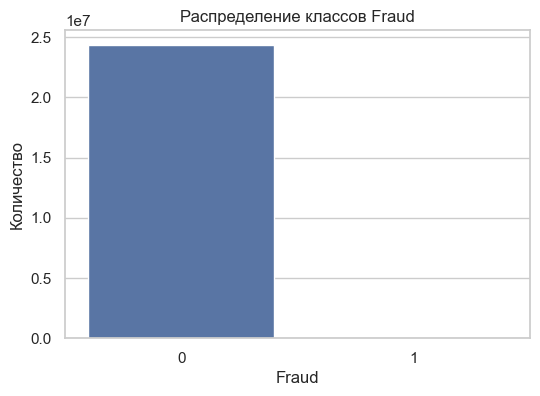

In [25]:
# Начнем с анализа распределения целевой переменной Fraud. Посмотрим на баланс классов.
print('Количество классов Fraud:')
display(data['Fraud'].value_counts().to_frame('count'))

print('\nДоли классов Fraud:')
display(data['Fraud'].value_counts(normalize=True).mul(100).round(3).to_frame('percent'))

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Fraud')
plt.title('Распределение классов Fraud')
plt.xlabel('Fraud')
plt.ylabel('Количество')
plt.show()

### 2.3.2 Распределение транзакций по времени

,transactions_count
Timestamp,
1991,1585
1992,5134
1993,8378
1994,14316
1995,20928
1996,29945
1997,49753
1998,78345
1999,118250


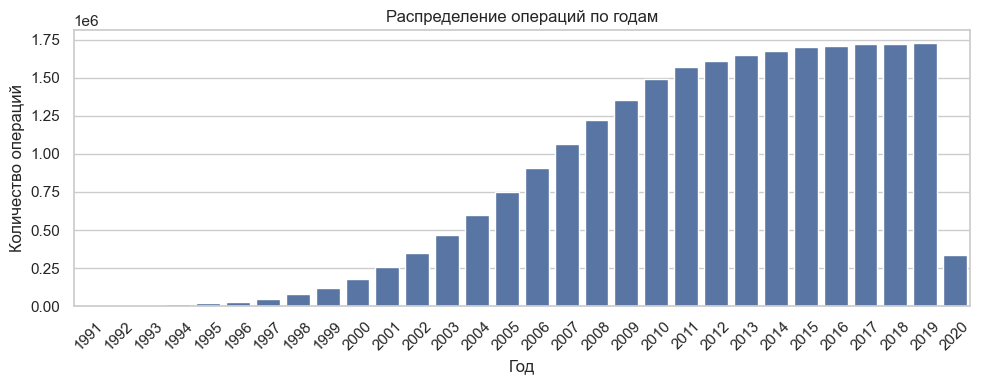

In [26]:
# Как и предполагалось, у нас огромный дисбаланс классов - только 0.122% транзакций являются мошенническими. 
# Учтём это при дальнейшем анализе и при построении модели.
# Теперь посмотрим на распределение транзакций по времени. Посмотрим на распределение по годам.

year_counts = data['Timestamp'].dt.year.value_counts().sort_index()
display(year_counts.to_frame('transactions_count'))

plt.figure(figsize=(10, 4))
sns.countplot(x=data['Timestamp'].dt.year)
plt.title('Распределение операций по годам')
plt.xlabel('Год')
plt.ylabel('Количество операций')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Понимаем, что наибольшее число данных у нас имеется за 2007-2019 годы, а до 1997 года транзакций совсем мало. 

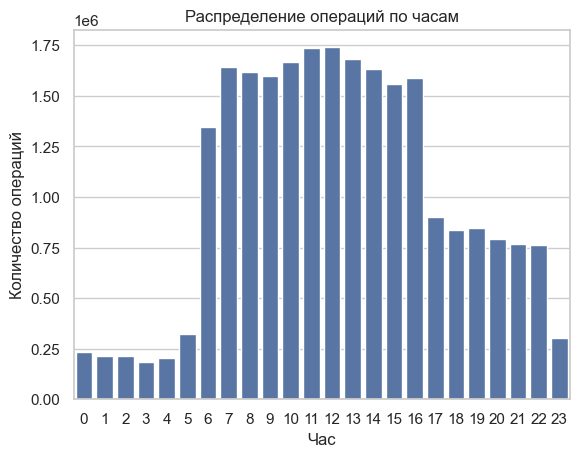

In [27]:
# Смотрим на распределение по часам суток
sns.countplot(x=data['Timestamp'].dt.hour)
plt.title('Распределение операций по часам')
plt.xlabel('Час')
plt.ylabel('Количество операций')
plt.show()

<Axes: xlabel='Timestamp', ylabel='count'>

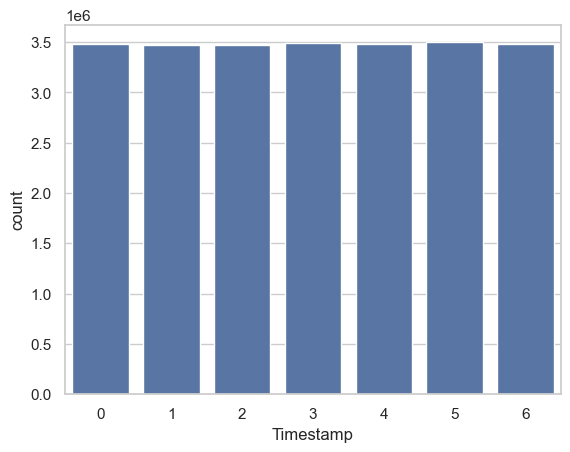

In [28]:
# Смотрим на распределение по дням недели
sns.countplot(x=data['Timestamp'].dt.dayofweek)

Делаем выводы - число транзакций примерно одинаково во все дни недели, а вот по времени пик активности с 6 до 16

### 2.3.4 Распределение транзакций по суммам. Обработка отрицательных и нулевых транзакций.

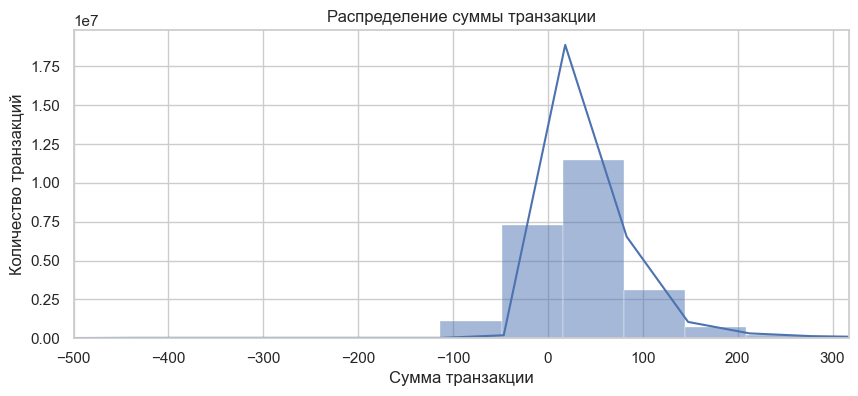

In [29]:
# Анализируем распределение числовых признаков. Начнём с суммы транзакции Amount. Посмотрим на её распределение и на наличие выбросов.
plt.figure(figsize=(10, 4))
sns.histplot(data['Amount'], bins=200, kde=True)
plt.title('Распределение суммы транзакции')
plt.xlabel('Сумма транзакции')
plt.ylabel('Количество транзакций')
plt.xlim(data['Amount'].min(), data['Amount'].quantile(0.99))  # ограничиваем x для лучшей видимости
plt.show()


Видим наличие отрицательных транзакций - возвратов. Необходимо будет проверить: это возвраты после fraud или просто обычные возвраты товаров.

In [30]:
# Проверяем есть ли строки, где Amount < 0 и Fraud == 1
negative_fraud = data[(data['Amount'] < 0) & (data['Fraud'] == 1)]
print(f"Количество строк с Amount < 0 и Fraud = 1: {len(negative_fraud)}")
display(negative_fraud.head())

Количество строк с Amount < 0 и Fraud = 1: 1125


,User,Card,Timestamp,Amount,Use_Chip,Is_Online,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,Merchant_USA,MCC,Has_Error,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,Is_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year
4112,0,0,2015-11-20 07:42:00,-473.000000,0,1,3558,ONLINE,ONLINE,Unknown,0,3640,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295.000000,2002-09-01,2008
13699,0,3,2008-10-20 09:23:00,-298.000000,0,0,59474,Corona,CA,92881.000000,1,3722,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,3,Visa,Credit,4879494103069057,2024-08-31,693,0,1,12400.000000,2003-01-01,2012
57552,2,1,2018-01-10 17:28:00,-85.000000,0,0,22204,Rome,Italy,Unknown,0,5541,0,No_Error,1,Saanvi Lee,81,67,1938,11,0,766 Third Drive,0,West Covina,CA,91792,34.020000,-117.889999,22681.000000,33483.000000,196.000000,698,5,1,Mastercard,Debit,5804499644308599,2023-07-31,258,0,2,27480.000000,2002-03-01,2008
57728,2,1,2018-04-09 18:39:00,-95.000000,0,0,59935,Rome,Italy,Unknown,0,5499,0,No_Error,1,Saanvi Lee,81,67,1938,11,0,766 Third Drive,0,West Covina,CA,91792,34.020000,-117.889999,22681.000000,33483.000000,196.000000,698,5,1,Mastercard,Debit,5804499644308599,2023-07-31,258,0,2,27480.000000,2002-03-01,2008
107988,5,0,2016-04-05 15:16:00,-471.000000,0,1,52923,ONLINE,ONLINE,Unknown,0,3504,0,No_Error,1,Aldo Walker,42,70,1977,10,1,58 Birch Lane,1,Davenport,IA,52803,41.549999,-90.599998,20599.000000,41997.000000,0.000000,704,3,0,Visa,Credit,4099623033306950,2021-09-30,74,1,2,9900.000000,2002-01-01,2019


In [31]:
# строки с отрицательными фрод-транзакциями
negative_fraud = data[(data['Amount'] < 0) & (data['Fraud'] == 1)].copy()

# добавим модуль суммы
negative_fraud['_Abs_Amount'] = negative_fraud['Amount'].abs()
data['_Abs_Amount'] = data['Amount'].abs()

# колонки для сравнения
cols_to_match = [c for c in data.columns if c not in ['Timestamp','Amount']]

# ищем совпадения
matches = negative_fraud.merge(
    data,
    on=cols_to_match + ['_Abs_Amount'],
    suffixes=('_refund','_purchase')
)

display(matches.head())
print("Refund с найденной покупкой:",
      matches['Timestamp_refund'].nunique())
# удаляем временные столбцы
data.drop(columns=['_Abs_Amount'], inplace=True, errors='ignore')
negative_fraud.drop(columns=['_Abs_Amount'], inplace=True, errors='ignore')

,User,Card,Timestamp_refund,Amount_refund,Use_Chip,Is_Online,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,Merchant_USA,MCC,Has_Error,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,Is_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year,_Abs_Amount,Timestamp_purchase,Amount_purchase
0,0,0,2015-11-20 07:42:00,-473.000000,0,1,3558,ONLINE,ONLINE,Unknown,0,3640,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295.000000,2002-09-01,2008,473.000000,2015-11-16 11:20:00,473.000000
1,0,0,2015-11-20 07:42:00,-473.000000,0,1,3558,ONLINE,ONLINE,Unknown,0,3640,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,0,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295.000000,2002-09-01,2008,473.000000,2015-11-20 07:42:00,-473.000000
2,0,3,2008-10-20 09:23:00,-298.000000,0,0,59474,Corona,CA,92881.000000,1,3722,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,3,Visa,Credit,4879494103069057,2024-08-31,693,0,1,12400.000000,2003-01-01,2012,298.000000,2008-10-12 15:58:00,298.000000
3,0,3,2008-10-20 09:23:00,-298.000000,0,0,59474,Corona,CA,92881.000000,1,3722,0,No_Error,1,Hazel Robinson,53,66,1966,11,0,462 Rose Lane,0,La Verne,CA,91750,34.150002,-117.760002,29278.000000,59696.000000,127613.000000,787,5,3,Visa,Credit,4879494103069057,2024-08-31,693,0,1,12400.000000,2003-01-01,2012,298.000000,2008-10-20 09:23:00,-298.000000
4,2,1,2018-01-10 17:28:00,-85.000000,0,0,22204,Rome,Italy,Unknown,0,5541,0,No_Error,1,Saanvi Lee,81,67,1938,11,0,766 Third Drive,0,West Covina,CA,91792,34.020000,-117.889999,22681.000000,33483.000000,196.000000,698,5,1,Mastercard,Debit,5804499644308599,2023-07-31,258,0,2,27480.000000,2002-03-01,2008,85.000000,2018-01-10 17:13:00,85.000000


Refund с найденной покупкой: 1124


Мы выяснили, что в датасете есть тразнакции, в которых было обнаружено мошенничество и клиент получил возврат на ту же карту.
Мы не можем оставить такие транзакции т.к. наша задача - выявление мошенничества в момент авторизации. Если модель будет знать о том, что транзакция была отменена - это создаст "данные из будущего", которых не будет в реальности. Строить же тут отдельно временной ряд, что бы модель не знала о факте будущего возврата очень сложно и лишено смысла, т.к. признак мошенничества у нас и так есть, а информация о том, был ли
по конкретному признаку возврат или нет нам не важен для построения модели (т.е. нам не важны последствия мошенничества).
Обычные же возвраты нас также не интересуют, т.к. они выходят за пределы того, для чего нужна модель (она не должна предсказывать мошенничество при возвратах так-как это совсем другой тип операций со своими отдельными рисками).

In [32]:
# Проверяем транзакции с нулевой суммой
zero_amount = data[data['Amount'] == 0]

print("Количество строк:", len(zero_amount))
# Смотрим распределение Fraud среди транзакций с нулевой суммой
data[data['Amount'] == 0]['Fraud'].value_counts()

Количество строк: 20213


Fraud
0    20200
1       13
Name: count, dtype: int64

In [33]:
# Смотрим транзакции с нулевой суммой и Fraud == 1
zero_fraud = data[(data['Amount'] == 0) & (data['Fraud'] == 1)]

print("Количество строк:", len(zero_fraud))
display(zero_fraud)

Количество строк: 13


,User,Card,Timestamp,Amount,Use_Chip,Is_Online,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,Merchant_USA,MCC,Has_Error,Errors,Fraud,Person,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,User_Address,Is_Apartment,User_City,User_State,User_Zip,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Brand,Card_Type,Card_Number,Expires,CVV,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,PIN_Last_Changed_Year
1471008,120,1,2010-04-30 10:58:00,0.000000,0,1,31893,ONLINE,ONLINE,Unknown,0,5311,0,No_Error,1,Yehuda Jones,40,74,1979,9,1,1977 Lake Avenue,0,Woodland Hills,CA,91364,34.150002,-118.599998,47055.000000,95945.000000,222735.000000,772,2,1,Mastercard,Credit,5825403139414547,2013-05-31,531,1,2,16300.000000,2007-11-01,2009
2236576,182,0,2019-01-25 17:52:00,0.000000,1,0,11468,Rome,Italy,Unknown,0,5970,0,No_Error,1,Bentley Lopez,47,69,1972,11,1,6009 River Avenue,0,Canton,GA,30114,34.240002,-84.489998,25654.000000,52308.000000,135319.000000,679,1,0,Visa,Credit,4180974548713374,2023-05-31,975,1,1,21000.000000,2005-07-01,2009
2718455,229,1,2008-07-21 16:56:00,0.000000,0,1,13523,ONLINE,ONLINE,Unknown,0,5310,0,No_Error,1,Lucinda Nelson,53,67,1966,10,0,456 Lincoln Boulevard,1,Orchard Park,NY,14127,42.759998,-78.739998,30202.000000,61578.000000,85383.000000,602,2,1,Visa,Debit,4855497833896747,2020-02-29,610,1,2,27727.000000,2003-12-01,2009
4625800,395,1,2007-08-29 13:56:00,0.000000,0,1,60569,ONLINE,ONLINE,Unknown,0,5300,0,No_Error,1,Rodrigo Rodriguez,68,65,1951,12,1,46 Lincoln Lane,1,Long Beach,CA,90808,33.820000,-118.110001,32079.000000,50184.000000,27778.000000,732,4,1,Visa,Credit,4281818687372228,2020-11-30,956,1,1,15100.000000,2005-06-01,2011
7317713,618,1,2018-09-12 12:17:00,0.000000,1,0,86438,Rome,Italy,Unknown,0,5499,0,No_Error,1,Romina Smith,59,63,1960,11,0,4701 Littlewood Drive,0,Tampa,FL,33618,27.950001,-82.480003,28916.000000,58959.000000,109358.000000,598,2,1,Visa,Debit,4632545212498675,2023-08-31,330,1,2,21439.000000,2017-10-01,2017
13024110,1073,1,2007-09-27 16:40:00,0.000000,0,1,16798,ONLINE,ONLINE,Unknown,0,4121,0,No_Error,1,London Garcia,34,66,1985,10,1,539 Maple Drive,1,Kernersville,NC,27284,36.110001,-80.070000,23738.000000,48398.000000,138998.000000,642,3,1,Mastercard,Debit (Prepaid),5525521386256143,2016-11-30,10,1,2,33.000000,2006-06-01,2013
14591794,1195,0,2018-01-12 19:46:00,0.000000,1,0,22204,Rome,Italy,Unknown,0,5541,0,No_Error,1,Holland Braun,45,63,1975,1,0,96493 Valley Stream Avenue,0,Bethlehem,CT,6751,41.630001,-73.209999,26674.000000,54384.000000,69717.000000,622,3,0,Amex,Credit,359230628127716,2019-05-31,198,1,2,6600.000000,2012-11-01,2012
15202024,1242,4,2019-08-15 13:11:00,0.000000,1,0,11468,Rome,Italy,Unknown,0,5970,0,No_Error,1,Noa Robinson,77,67,1942,12,0,7239 Hill Lane,0,Lebanon,PA,17042,40.340000,-76.419998,20983.000000,30457.000000,19314.000000,520,5,4,Visa,Credit,4780949143263441,2023-08-31,540,1,2,7700.000000,2014-03-01,2014
16424186,1330,6,2018-02-12 17:47:00,0.000000,1,0,86438,Rome,Italy,Unknown,0,5499,0,No_Error,1,Brooklyn Reed,50,68,1969,12,0,773 12th Street,0,Oshkosh,WI,54901,44.009998,-88.550003,19573.000000,39911.000000,93823.000000,625,7,6,Visa,Credit,4929393429782613,2021-10-31,648,1,1,13700.000000,2005-02-01,2012
17519669,1419,3,2008-02-17 21:24:00,0.000000,0,0,56239,Parsippany,NJ,7054.000000,1,5300,0,No_Error,1,Mathias Gao,52,66,1967,4,1,304 Third Boulevard,0,Parsippany,NJ,7054,40.849998,-74.400002,34756.000000,70862.000000,16595.000000,745,5,3,Mastercard,Debit,5225250785593496,2024-12-31,71,1,2,34731.000000,1997-10-01,2011


Технически сумма 0 возможна в нескольки ситуациях: тестовая транзакция, установка регулярного платежа, транзакция для получения кода (в описании транзакции приходит код, который нужно куда-то ввести). По-этому нулевые транзакции это не ошибки - это просто операции, в которых деньги не списывались мгновенно. Они тоже могут быть мошенническими (например, установка регулярного списания). По-этому мы не удаляем нулевые транзакции.

In [34]:
# Удалим строки с Amount < 0
data = data[~(data['Amount'] < 0)]
print("Осталось строк:", len(data))
print("Минимальная сумма:", data['Amount'].min())

Осталось строк: 23142217
Минимальная сумма: 0.0


In [35]:
# Заново проверим распределения целевой переменной Fraud.
print('Количество классов Fraud:')
display(data['Fraud'].value_counts().to_frame('count'))

print('\nДоли классов Fraud:')
display(data['Fraud'].value_counts(normalize=True).mul(100).round(3).to_frame('percent'))

Количество классов Fraud:


,count
Fraud,
0,23113585
1,28632



Доли классов Fraud:


,percent
Fraud,
0,99.876000
1,0.124000


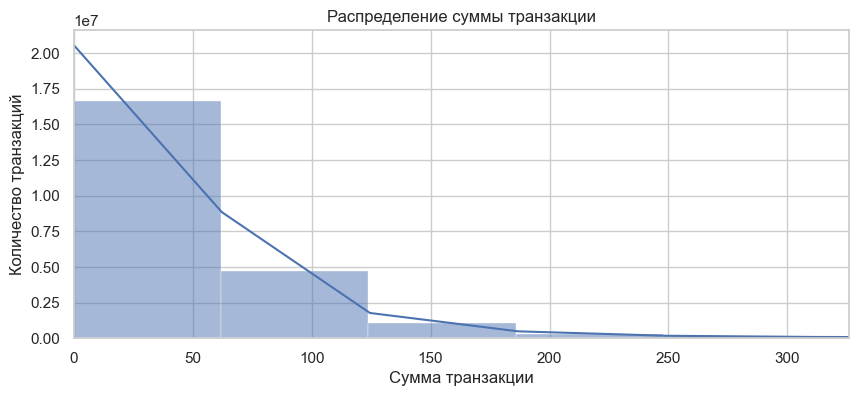

In [36]:
# Вернёмся к распределению суммы транзакции.
plt.figure(figsize=(10, 4))
sns.histplot(data['Amount'], bins=200, kde=True)
plt.title('Распределение суммы транзакции')
plt.xlabel('Сумма транзакции')
plt.ylabel('Количество транзакций')
plt.xlim(data['Amount'].min(), data['Amount'].quantile(0.99))  # ограничиваем x для лучшей видимости
plt.show()

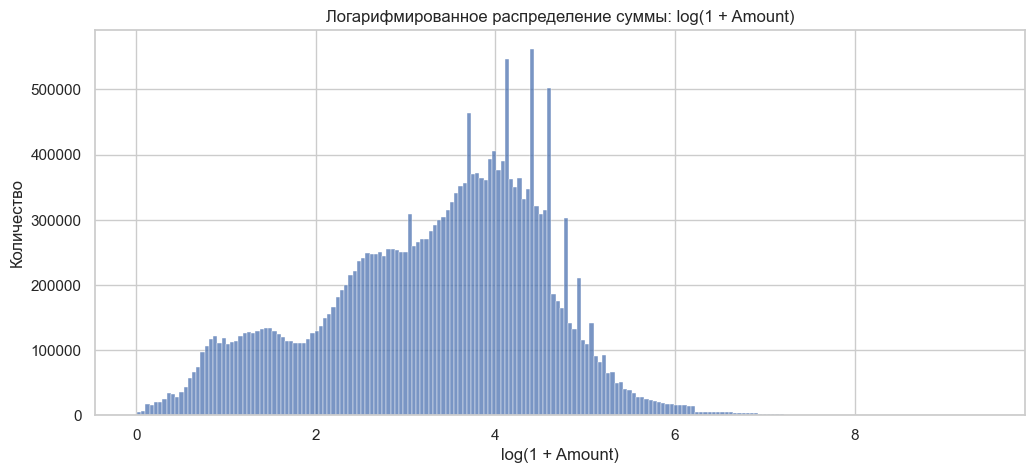

In [37]:
# "Хвост" очень длинный, посмотрим логарифм суммы транзакции
plt.figure(figsize=(12, 5))

sns.histplot(
    np.log1p(data.loc[data['Amount'] > 0, 'Amount']),
    bins=200
)

plt.title('Логарифмированное распределение суммы: log(1 + Amount)')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Количество')

plt.show()

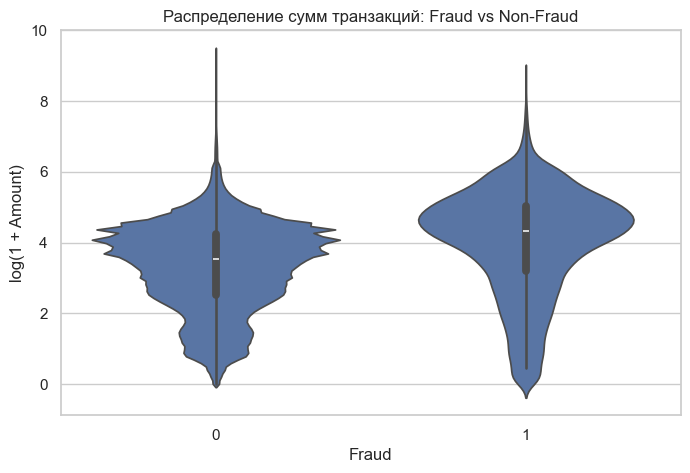

In [38]:
# Посмотрим на распределение логарифма суммы транзакции для классов Fraud и Non-Fraud. Это поможет нам понять, отличаются ли эти классы по сумме транзакции.
plt.figure(figsize=(8,5))

sns.violinplot(
    data=data,
    x='Fraud',
    y=np.log1p(data['Amount'])
)

plt.title('Распределение сумм транзакций: Fraud vs Non-Fraud')
plt.xlabel('Fraud')
plt.ylabel('log(1 + Amount)')

plt.show()

Мошеннические транзакции имеют тенденцию иметь больший размер, чем не мошеннические

### 2.3.5 Распределение числовых признаков

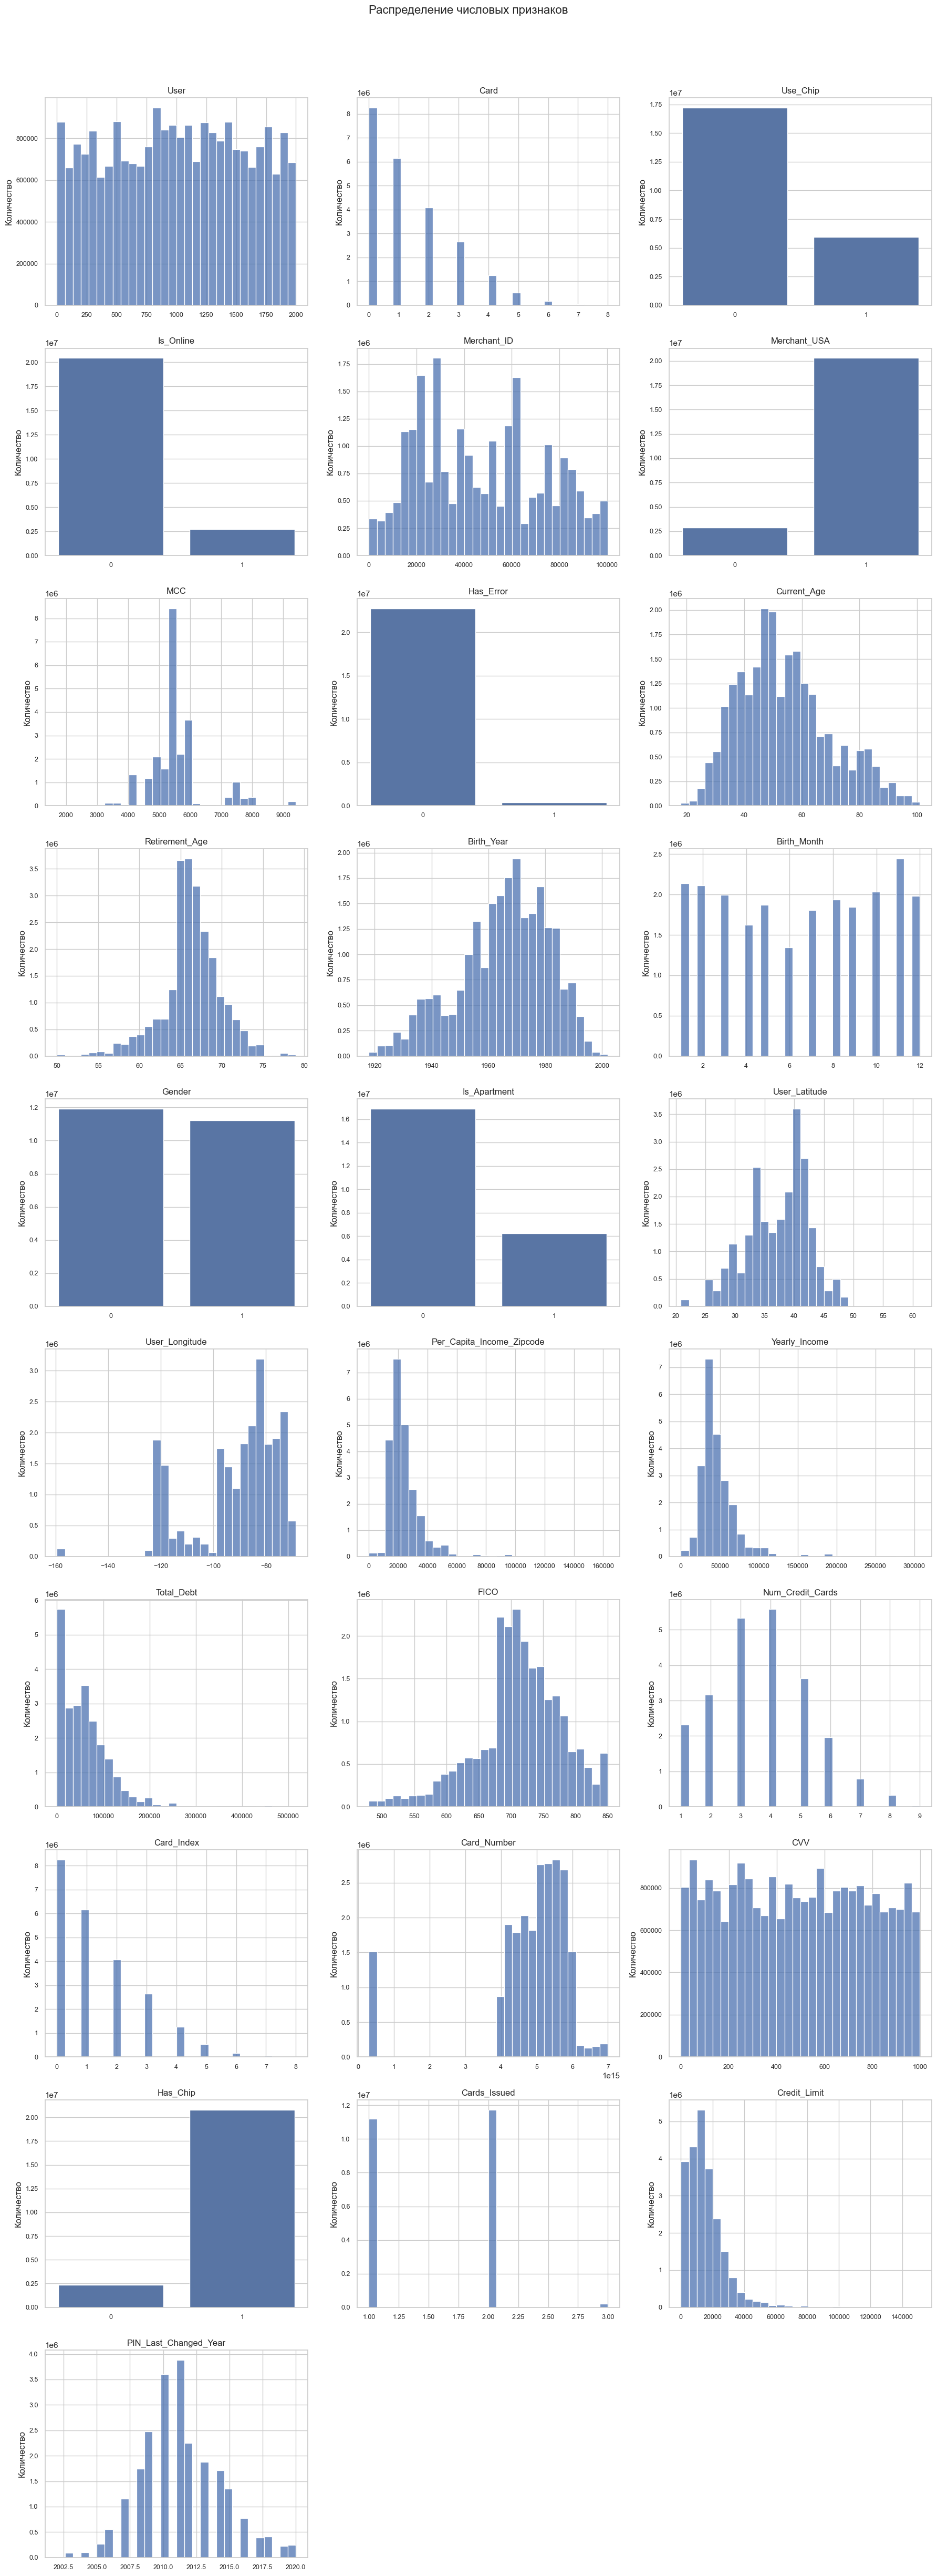

In [39]:
num_cols = data.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']).drop(columns=['Fraud'], errors='ignore').columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols.drop(['Amount'])): # исключаем Amount так-как мы уже его проанализировали
    ax = plt.subplot(n_rows, n_cols, i + 1)

    if data[col].nunique(dropna=True) <= 2:
        sns.countplot(data=data, x=col, ax=ax)
    else:
        sns.histplot(data=data, x=col, bins=30, ax=ax)

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [40]:
# Выводим описательную статистику для числовых признаков (используем для выводов)
display(data[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
User,23142217.000000,1001.907951,569.595849,0.000000,513.000000,1008.000000,1477.000000,1999.000000
Card,23142217.000000,1.353565,1.409780,0.000000,0.000000,1.000000,2.000000,8.000000
Amount,23142217.000000,51.469589,74.171173,0.000000,11.450000,33.130001,68.000000,12390.500000
Use_Chip,23142217.000000,0.256746,0.436838,0.000000,0.000000,0.000000,1.000000,1.000000
Is_Online,23142217.000000,0.116822,0.321209,0.000000,0.000000,0.000000,0.000000,1.000000
Merchant_ID,23142217.000000,47582.630453,26206.119766,0.000000,24827.000000,45268.000000,69219.000000,100342.000000
Merchant_USA,23142217.000000,0.877016,0.328419,0.000000,1.000000,1.000000,1.000000,1.000000
MCC,23142217.000000,5573.649950,890.033527,1711.000000,5300.000000,5499.000000,5813.000000,9402.000000
Has_Error,23142217.000000,0.016028,0.125583,0.000000,0.000000,0.000000,0.000000,1.000000
Current_Age,23142217.000000,53.931644,15.865137,18.000000,42.000000,52.000000,63.000000,101.000000


Из распределения данных видим следующее:
Идентификаторы пользователей - равномерное распределение. Это означает, что нет пользователей с доминирующим влиянием на данные.
Идентификаторы карт, номера карт и их индексы - судя по распределению нет полезной информации.
Все эти признаки нельзя использовать для обучения, т.к. система может запомнить их вместо реальных данных.
Большинство транзакций совершены в США, являются "очными" покупками без использования чипа. Нужно дополнительно проверить, меняется ли эта тенденция с годами и является ли она фактором риска.
Подтверждаем, что датасет основан именно на США как "домашнем регионе" - т.е. данные характерны именно для США.
MCC-коды (категория бизнеса) имеют не равномерное распределение, нужно будет сравнивать распределение для мошеннических и обычных транзакций.
Финансовые показатели ассиметричны, свдинуты влево с длинным "хвостом" справа, что является ожидаеммым распределением для финансов.
Кредитный рейтинг (FICO) соответствует ожидаеммому распределению (если сравнить с доступной статистикой за 2020-2021 годы).
Число кредитных карт у большой части клиентов от 2 до 5.

Ошибки встречаются редко, нужно проверять, бывают ли ошибочные и одновременно мошеннические транзакции.
Возвраст, код рождения и возраст выхода на пенсию имеют нормальное распределение, что характерно для "биологических признаков".
Месяц рождения - равномерное распределение, что ожидаеммо. Данные не имеют явных "перекосов" по демографии.

Интересным является то, что год смены пин-кода тоже имеет распределение, близкое к нормальному. Скорее всего, это последствие Центральной предельной теоремы, ведь сама смена пин-кода зависит от очень многих факторов. 

Потенциально полезные признаки: Is_Online, Use_Chip,Merchant_USA,Has_Error,MCC,FICO,Total_Debt,Credit_Limit,Yearly_Income. 
Нужно будет проверять зависимость пола, возвраста и фактора выхода на пенсию, времени со дня смены пин-кода.
Точно нужно будет удалять все индентификаторы.


### 2.3.6 Распределение категориальных признаков

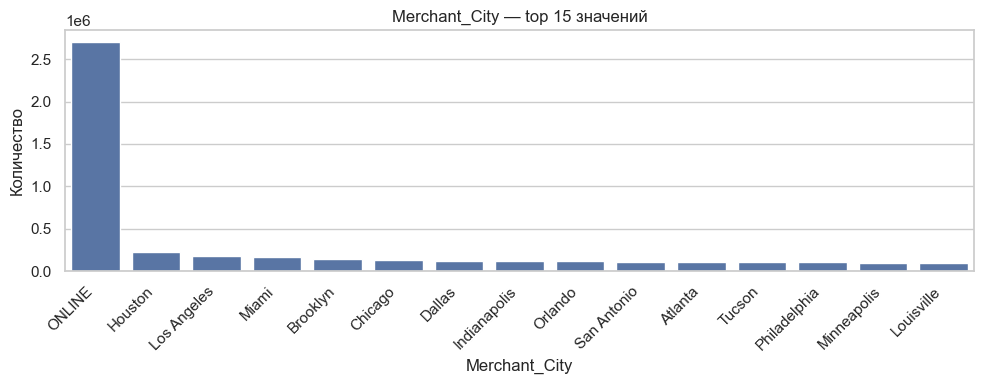

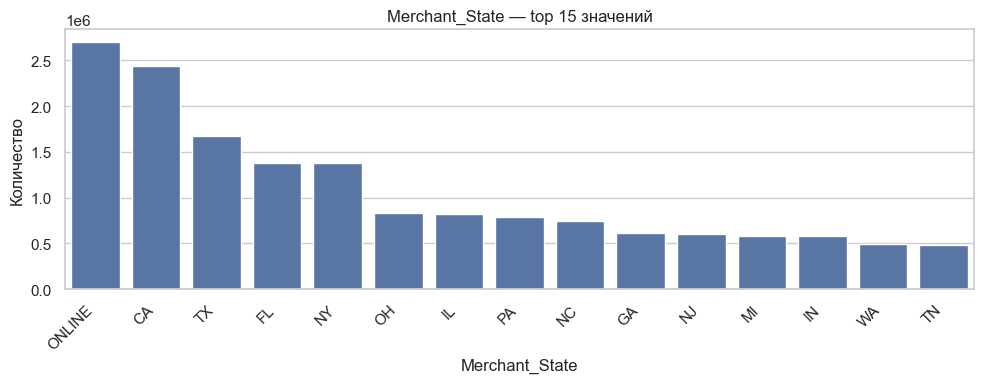

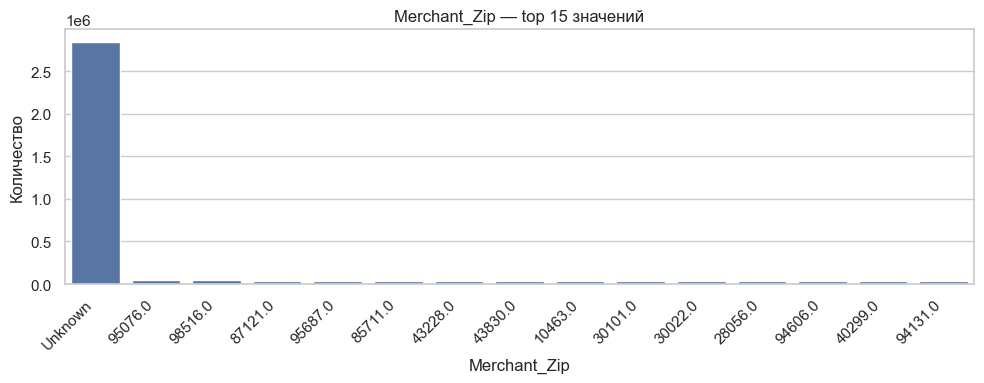

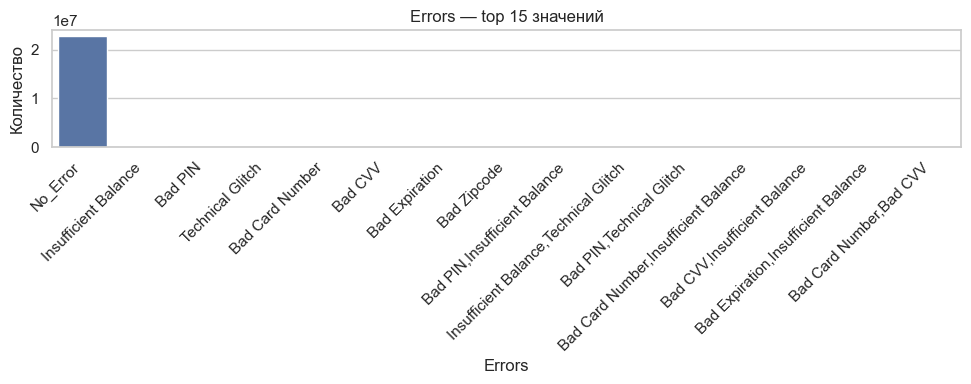

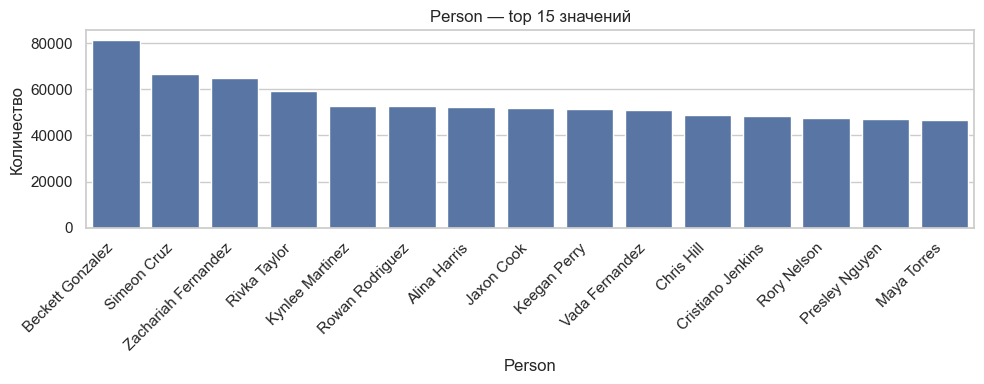

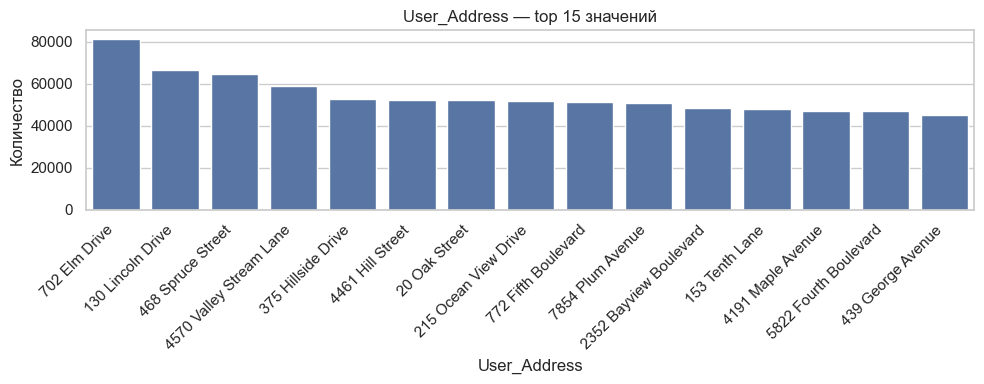

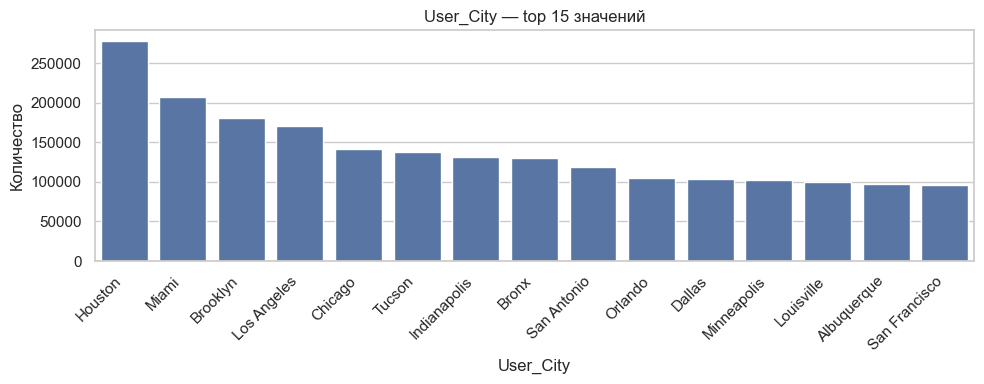

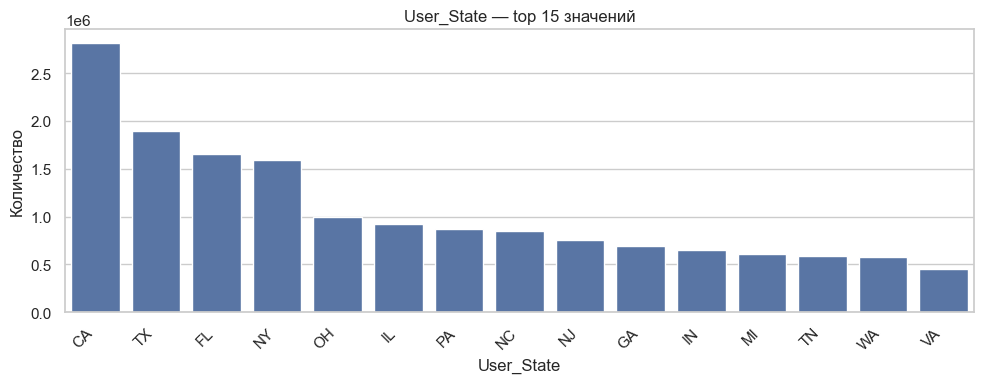

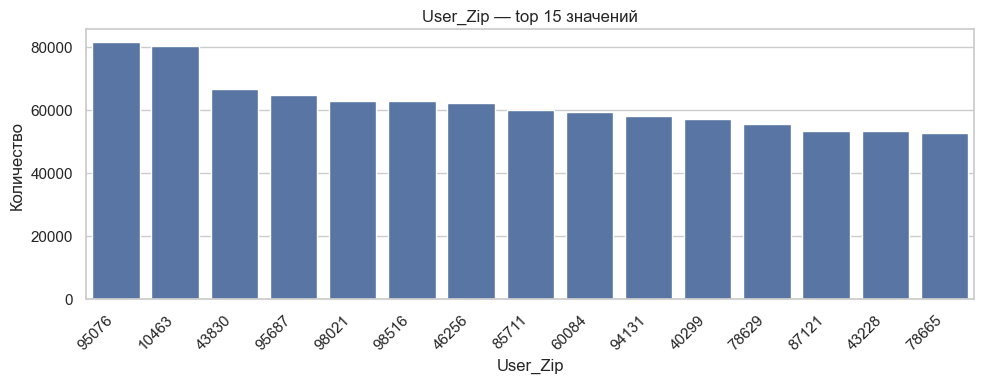

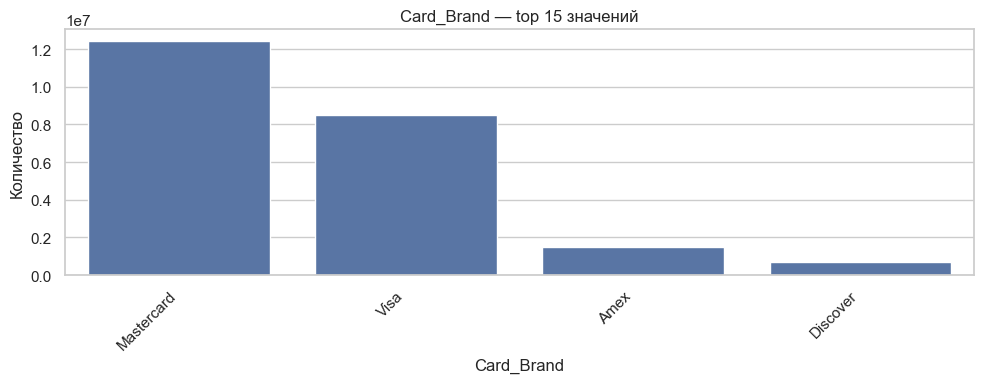

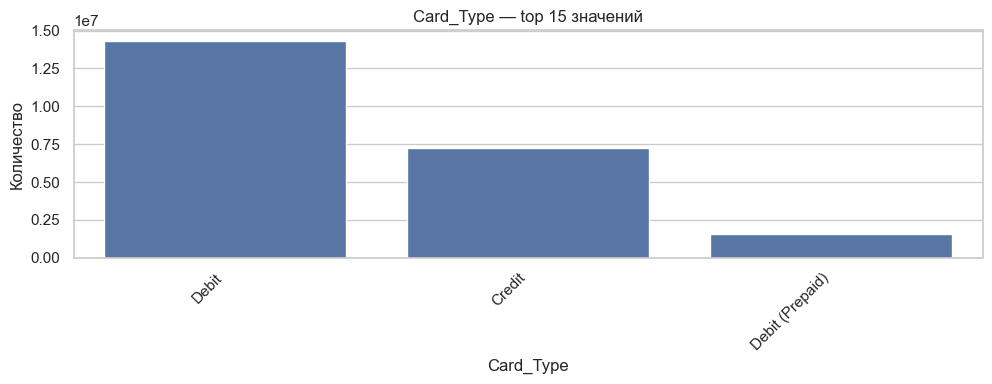

In [41]:
# Посмотрим распределение категориальных признаков. Возьмём не более топ-15 значений что бы составить общее представление
cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['Timestamp']]

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    top_values = data[col].astype(str).value_counts(dropna=False).head(15)
    sns.barplot(x=top_values.index, y=top_values.values)
    plt.title(f'{col} — top 15 значений')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

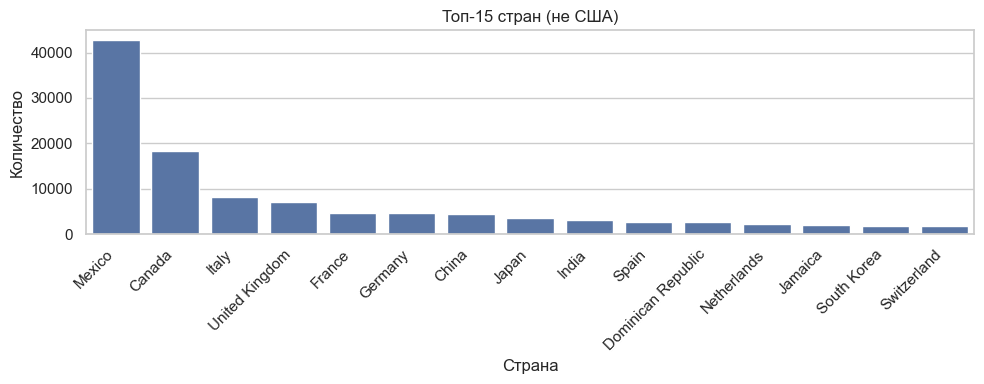

In [42]:
# Получаем топ-15 стран (не штатов) для не США
top_countries = (
    data.loc[(data['Merchant_USA'] == 0) & (data['Is_Online'] == 0), 'Merchant_State'] # выбираем только не США и не он-лайн транзакции
    .astype(str)
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Топ-15 стран (не США)')
plt.xlabel('Страна')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Мы видим, что Online - которые не является городом, занимает топ-1. Это может привести к искажению результатов. Придётся изменяить эти признаки. Нужно будет создавать два отдельных датасета. Для логистической регрессии будем использовать категориальный признак Unknown. Для деревьев решений поменяем Online на NaN.
Возможно, нужно будет заменить города с редкой частотой на Other - это упростить кодирование или применить частотное кодирование ко всем городам. Частота упоминания города действительно реальный признак, на котором модель может обучаться. 

### 2.3.7 Корреляция признаков между собой

In [43]:
# Создаём матрицу коррелций для числовых признаков
corr_numeric = data.corr(numeric_only=True)
corr_numeric

,User,Card,Amount,Use_Chip,Is_Online,Merchant_ID,Merchant_USA,MCC,Has_Error,Fraud,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,Is_Apartment,User_Latitude,User_Longitude,Per_Capita_Income_Zipcode,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Index,Card_Number,CVV,Has_Chip,Cards_Issued,Credit_Limit,PIN_Last_Changed_Year
User,1.000000,0.010483,-0.016735,0.007286,-0.027124,0.017333,0.027583,0.010738,-0.000952,0.000518,0.030132,-0.038270,-0.029502,-0.039171,-0.015353,0.032982,0.061208,0.028898,-0.056274,-0.050718,-0.028866,0.044711,0.004215,0.010483,-0.031357,-0.020908,-0.008739,-0.026962,-0.035759,0.015429
Card,0.010483,1.000000,-0.006164,-0.032189,-0.017161,0.020237,0.016056,0.012183,-0.001150,0.006794,0.229035,0.114566,-0.228958,-0.007065,0.003780,-0.029180,-0.006484,-0.045400,0.003309,-0.021169,-0.126355,0.178277,0.593837,1.000000,0.010473,-0.017144,-0.039545,0.008325,0.016464,-0.015892
Amount,-0.016735,-0.006164,1.000000,-0.019253,0.035379,-0.011215,-0.037437,-0.098837,0.027432,0.034380,-0.005309,-0.009632,0.005282,-0.010420,-0.005837,-0.004829,0.011175,0.008158,0.132000,0.129964,0.060633,-0.017058,-0.010070,-0.006164,-0.037213,0.005432,0.004059,0.005883,0.090494,0.001795
Use_Chip,0.007286,-0.032189,-0.019253,1.000000,-0.213758,0.018893,0.205712,0.061447,-0.004943,-0.007311,-0.069825,0.002093,0.070101,-0.019702,-0.006993,0.008552,0.015257,-0.001052,-0.011849,-0.006291,0.012709,-0.008535,-0.040741,-0.032189,0.003579,0.002337,0.197390,-0.002477,0.002515,0.109263
Is_Online,-0.027124,-0.017161,0.035379,-0.213758,1.000000,-0.091264,-0.971221,-0.263584,0.019364,0.053991,-0.005936,-0.011570,0.005765,0.036627,-0.009663,-0.010136,-0.028768,0.017391,0.038043,0.030400,0.018547,-0.026486,-0.020715,-0.017161,-0.006971,-0.003338,0.017697,-0.006594,0.024095,-0.004596
Merchant_ID,0.017333,0.020237,-0.011215,0.018893,-0.091264,1.000000,0.088085,0.075683,-0.005847,0.004697,0.005156,-0.000830,-0.005021,-0.010363,-0.006515,0.006718,0.024407,0.015610,-0.007777,-0.005105,0.004714,0.003410,0.034444,0.020237,-0.005018,0.011684,0.001230,-0.000064,-0.003429,-0.000049
Merchant_USA,0.027583,0.016056,-0.037437,0.205712,-0.971221,0.088085,1.000000,0.261624,-0.018619,-0.075939,0.004162,0.011411,-0.003997,-0.034886,0.009216,0.010195,0.025399,-0.018111,-0.048995,-0.040687,-0.021714,0.025149,0.019115,0.016056,0.006929,0.002869,-0.016434,0.006819,-0.030370,0.004641
MCC,0.010738,0.012183,-0.098837,0.061447,-0.263584,0.075683,0.261624,1.000000,-0.013241,-0.010679,0.005119,0.019572,-0.005162,-0.012221,0.005036,-0.007045,0.003406,0.007903,-0.022187,-0.016416,-0.011885,0.014059,0.016573,0.012183,0.003064,0.011043,-0.017134,0.003776,-0.012845,0.006204
Has_Error,-0.000952,-0.001150,0.027432,-0.004943,0.019364,-0.005847,-0.018619,-0.013241,1.000000,0.007675,0.003174,-0.001479,-0.003216,0.001749,0.001097,0.001690,-0.004226,-0.000607,-0.008736,-0.009601,-0.005508,0.010360,0.000070,-0.001150,0.001013,-0.000668,0.001404,0.002504,-0.000316,-0.001946
Fraud,0.000518,0.006794,0.034380,-0.007311,0.053991,0.004697,-0.075939,-0.010679,0.007675,1.000000,0.005548,0.001565,-0.005563,0.000149,-0.000678,-0.001502,-0.000862,-0.001470,-0.002678,-0.003153,-0.003197,0.002478,0.010263,0.006794,-0.000229,0.001331,0.000905,-0.000215,-0.003929,-0.000650


In [44]:
# Выводим список корреляция выше 0.7 (по абсолютному значению)
high_corr = (
    corr_numeric
    .where(np.triu(np.ones(corr_numeric.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature_1','Feature_2','Correlation']

high_corr = high_corr[high_corr['Correlation'].abs() > 0.7]

display(high_corr.sort_values('Correlation', ascending=False))

,Feature_1,Feature_2,Correlation
50,Card,Card_Index,1.000000
369,Per_Capita_Income_Zipcode,Yearly_Income,0.950447
111,Is_Online,Merchant_USA,-0.971221
246,Current_Age,Birth_Year,-0.999702


Text(0.5, 1.0, 'Корреляционная матрица для числовых признаков')

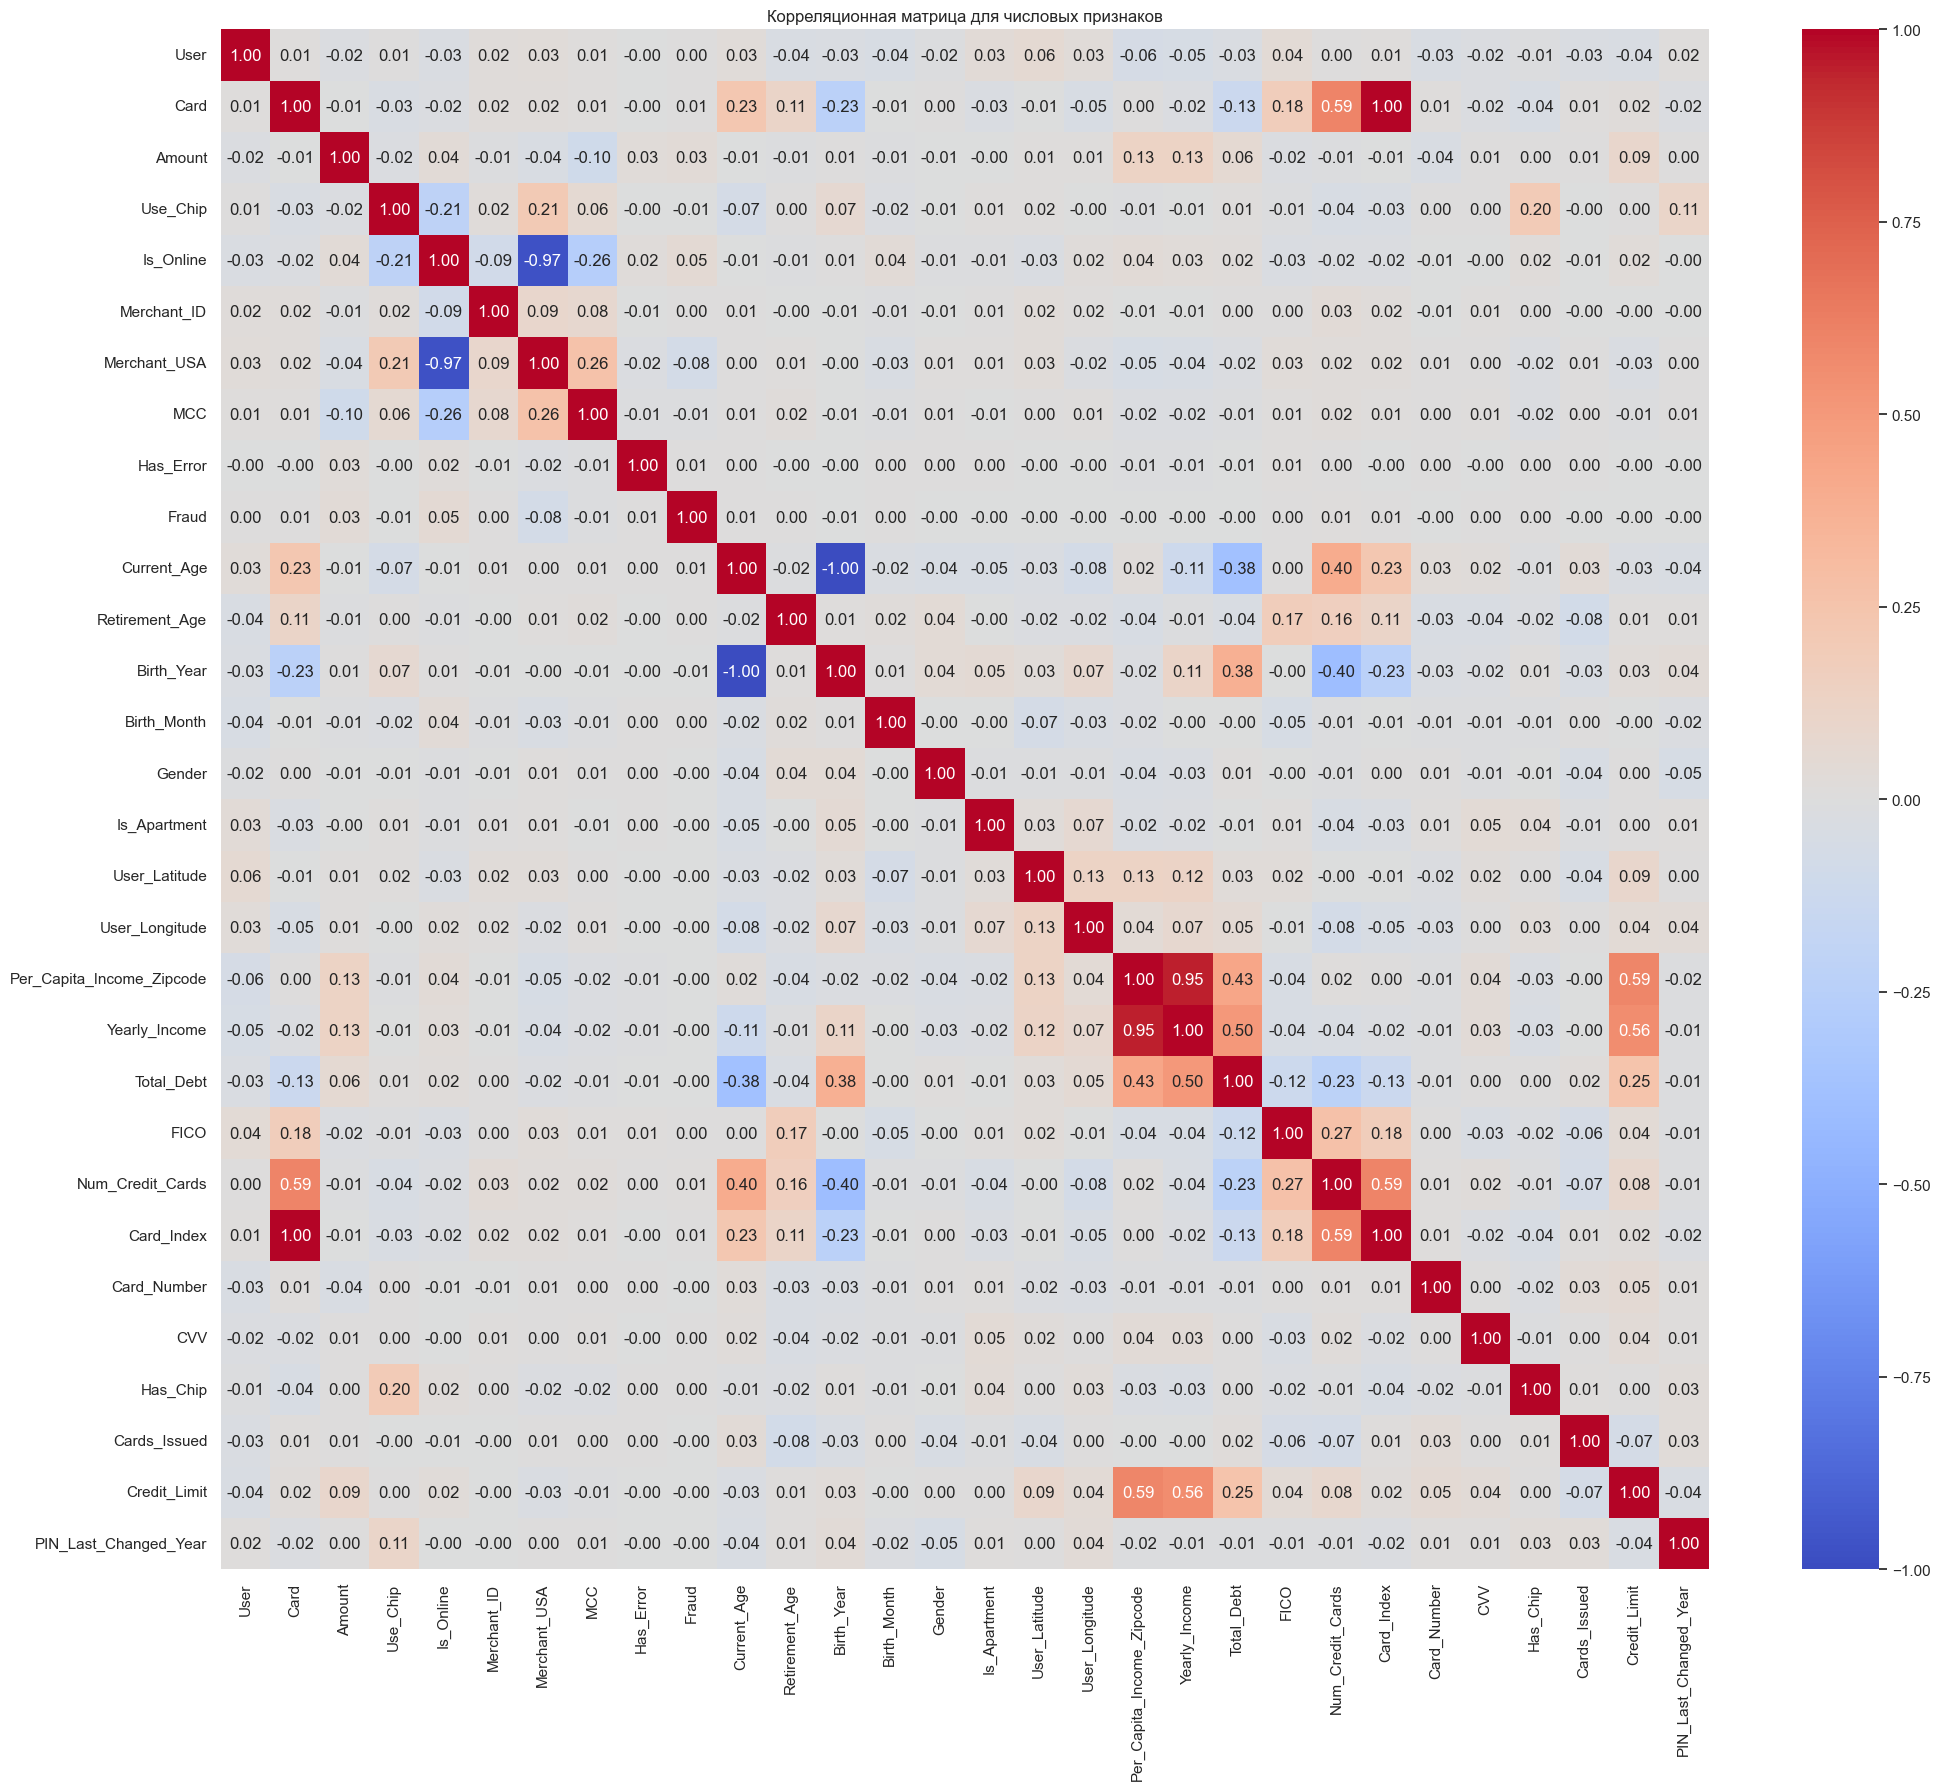

In [45]:
# Строим тепловую карту корреляций для числовых признаков
plt.figure(figsize=(24, 20))
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица для числовых признаков')

Мы имеем идентичные Card и Card_Index - что логично, т.к. это индексы, по которым мы "собирали" таблицу
Per_Capita_Income_Zipcode и Yearly_Income сильно скореллированы, но это объяснимо - человек живёт в "багатом" районе и много зарабатывает. Для моелей с регрессией уберём Per_Capita_Income_Zipcode - для нас важнее информация о том, какие у человека реальные доходы, а не насколько высок его потенциал этих доходов. Если бы у нас было много пропусков в доходах (например, данные были бы не полные) - мы могли бы тогда использовать оба признака. А так они просто показывают, что люди давали банку правдивую информацию.
Корреляция он-лайн покупок и признака того, что мерчант находится в США показывает, что один из признаков нужно убрать. Я думаю убрать нахождение в США - т.к. для обучения модели факт того, что транзакция является он-лайн важнее. Будем создавать отдельный признак Is_Foreign_Offline куда включим только физические транзакции за пределами США. 
Корреляция текущего возраста и даты рождения естественна. Пересчитаем текущий возраст используя год рождения, а потом удалим год рождения совсем. 

In [46]:
# Попробуем посмотреть корреляцию категориальных признаков с помощью статистического теста Cramer's V.

from scipy.stats import chi2_contingency
# Функция для расчёта Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))
# Колонки для анализа (возьмём и булевые признаки)
cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns

cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

cramers_matrix

,Merchant_City,Merchant_State,Merchant_Zip,Errors,Person,User_Address,User_City,User_State,User_Zip,Card_Brand,Card_Type
Merchant_City,1.000000,0.932612,0.993717,0.031646,0.573528,0.573474,0.702553,0.797175,0.600677,0.449748,0.426056
Merchant_State,0.932612,1.000000,0.482891,0.023079,0.401861,0.402581,0.382648,0.834958,0.402309,0.102754,0.101337
Merchant_Zip,0.993717,0.482891,1.000000,0.040363,0.710107,0.710001,0.765207,0.884604,0.743220,0.546336,0.519801
Errors,0.031646,0.023079,0.040363,1.000000,0.021446,0.021463,0.017732,0.004515,0.020981,0.009151,0.023095
Person,0.573528,0.401861,0.710107,0.021446,1.000000,0.999749,0.998378,0.997916,0.998439,0.687799,0.661230
User_Address,0.573474,0.402581,0.710001,0.021463,0.999749,1.000000,0.999749,0.999811,0.999724,0.688597,0.661236
User_City,0.702553,0.382648,0.765207,0.017732,0.998378,0.999749,1.000000,0.953085,1.000000,0.576442,0.547309
User_State,0.797175,0.834958,0.884604,0.004515,0.997916,0.999811,0.953085,1.000000,1.000000,0.119461,0.116715
User_Zip,0.600677,0.402309,0.743220,0.020981,0.998439,0.999724,1.000000,1.000000,1.000000,0.671792,0.640264
Card_Brand,0.449748,0.102754,0.546336,0.009151,0.687799,0.688597,0.576442,0.119461,0.671792,1.000000,0.361372


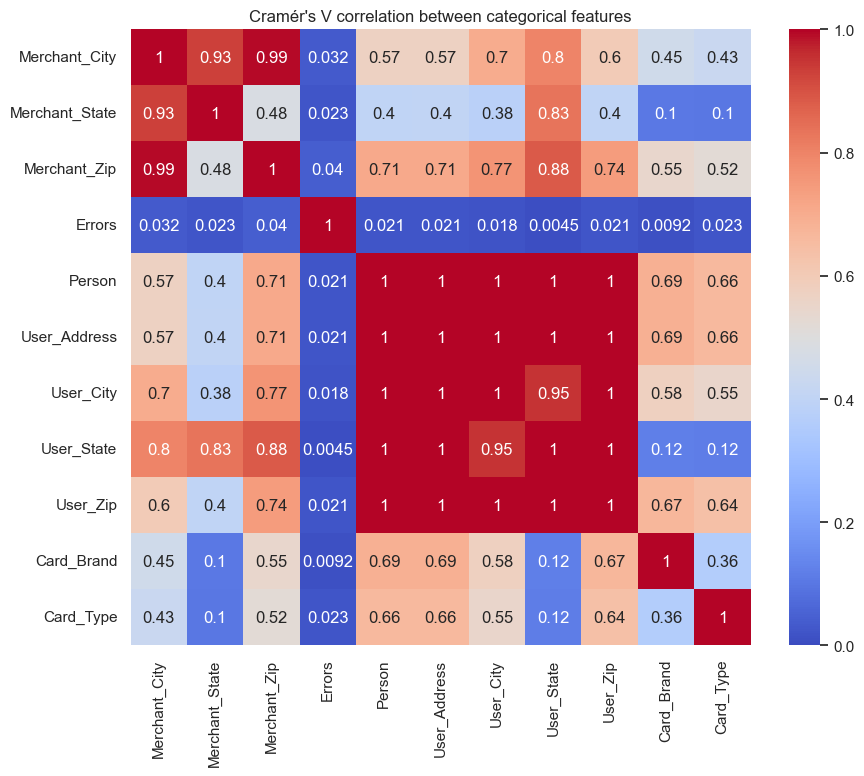

In [47]:
# Сделаем тепловую карту для Cramer's V.
plt.figure(figsize=(10,8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1
)

plt.title("Cramér's V correlation between categorical features")
plt.show()

In [48]:
# Выводим список корреляция выше 0.7 (по абсолютному значению)
high_cat_corr = (
    cramers_matrix
    .where(np.triu(np.ones(cramers_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_cat_corr.columns = ['Feature_1','Feature_2','Correlation']

high_cat_corr = high_cat_corr[high_cat_corr['Correlation'].abs() > 0.7]

display(high_cat_corr.sort_values('Correlation', ascending=False))

,Feature_1,Feature_2,Correlation
46,User_City,User_Zip,1.000000
49,User_State,User_Zip,1.000000
41,User_Address,User_State,0.999811
34,Person,User_Address,0.999749
40,User_Address,User_City,0.999749
42,User_Address,User_Zip,0.999724
37,Person,User_Zip,0.998439
35,Person,User_City,0.998378
36,Person,User_State,0.997916
1,Merchant_City,Merchant_Zip,0.993717


Имеем несколько признаков с очень высокой корреляцией.
1. Город проживания пользователя, страна проживания пользователя коррелируют с ZIP-кодом пользователя. Скорее всего мы будем удалять все признаки связанные с адресом пользователя, а оставлять только производные признаки (например, была ли транзакция в том же городе или стране). 
2. Есть аналогичная сильная корреляция в продавцах. Нужно будет оставить только один уровень географии - например, страну или город.
3. Самое важное, что мы видим - высокая корреляция между адресами пользователей и мерчантов. Это не мультиколлинеарность, а реальная зависимость - люди часто покупают товары в своём городе, штате или стране.

## 2.4 Анализ корреляции признаков с целевым признаком

In [61]:
# Корреляция числовых признаков с целевой переменной Fraud
corr_with_target = (
    data.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64'])
      .corr(numeric_only=True)['Fraud']
      .sort_values(ascending=False)
)

display(corr_with_target.to_frame('corr_with_Fraud'))

,corr_with_Fraud
Fraud,1.000000
Is_Online,0.053991
Amount,0.034380
Num_Credit_Cards,0.010263
Has_Error,0.007675
Card_Index,0.006794
Card,0.006794
Current_Age,0.005548
Merchant_ID,0.004697
FICO,0.002478


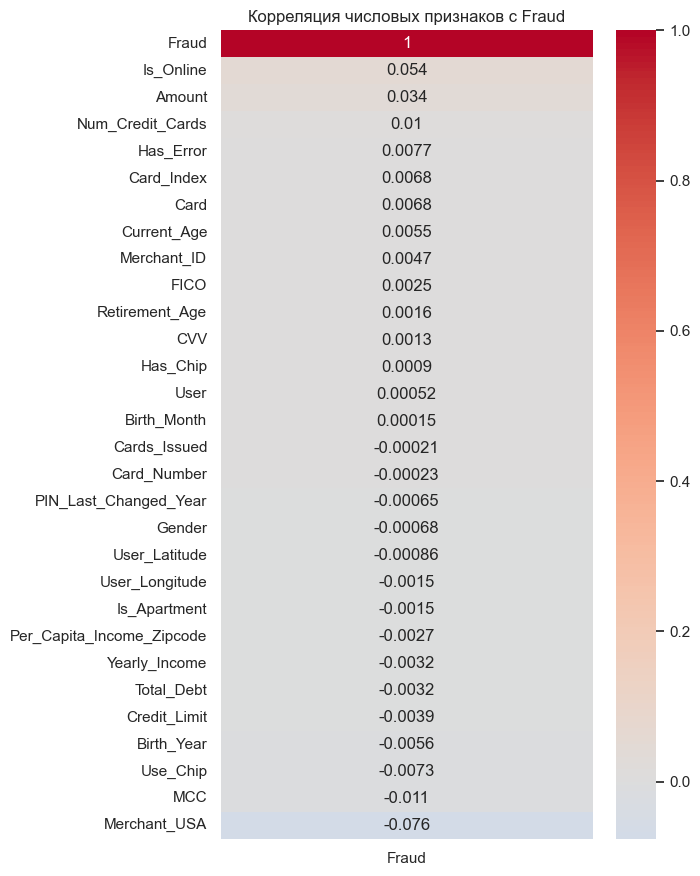

In [62]:
# Строим тепловую карту для корреляции числовых признаков с Fraud.
plt.figure(figsize=(6, max(4, len(corr_with_target) * 0.35)))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков с Fraud')
plt.show()

Линейная зависимость между числовыми признаками и целевым признаком очень маленькая. Очевидно, что важной будет именно комбинация признаков, а не какой-то признак отдельно. Можно заметить наибольшую корреляцию между он-лайн транзакцией и мошенничеством и суммой операции и мошенничеством. Т.е. операции в большой суммой и он-лайн транзакции более вероятно будут мошенническими. Есть обратная корреляция - если платёж совершен в США - вероятность ниже. Фактически, тут важен не факт нахождения в США, а внутренняя/иностранная транзакция. 
Есть зависимость от категории продавца. Ожидаеммо, многие признаки имеют минимальную корреляцию. Например, использование чипа уменьшает риск мошенничества, как и меньший возвраст. 
Главный вывод, который мы делаем - очень важно сохранить признак связанный с тем, является ли транзакция внутренней или внешней.

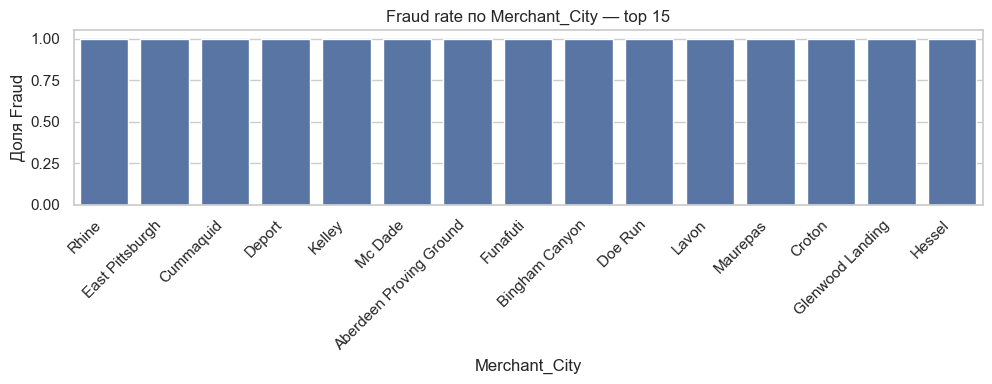

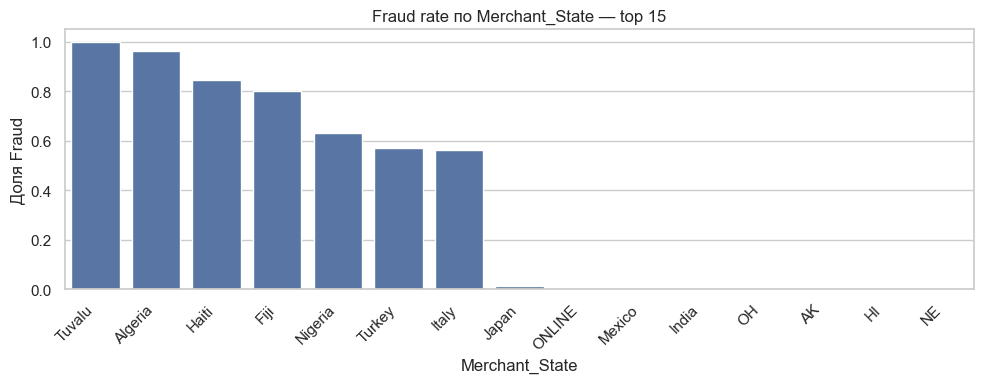

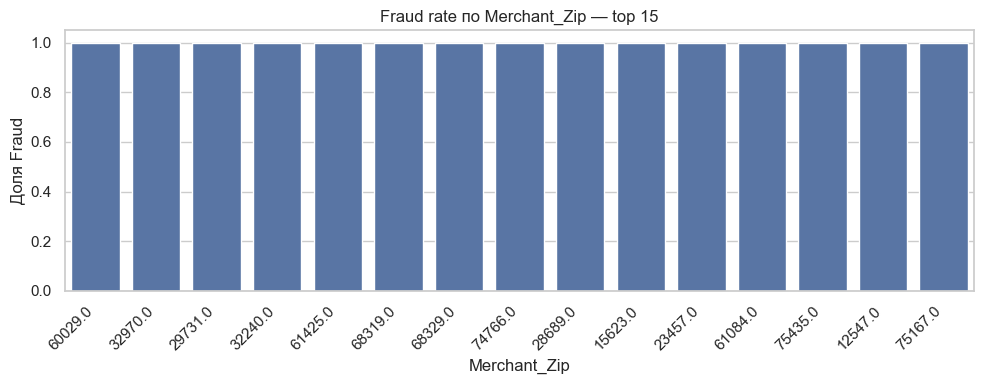

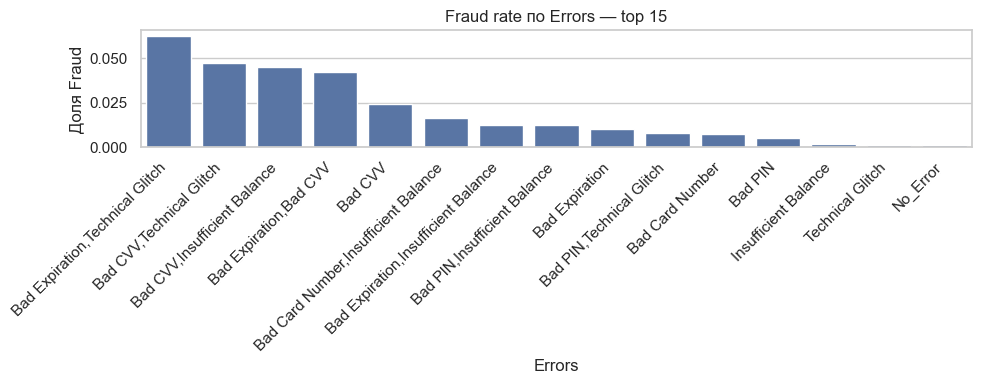

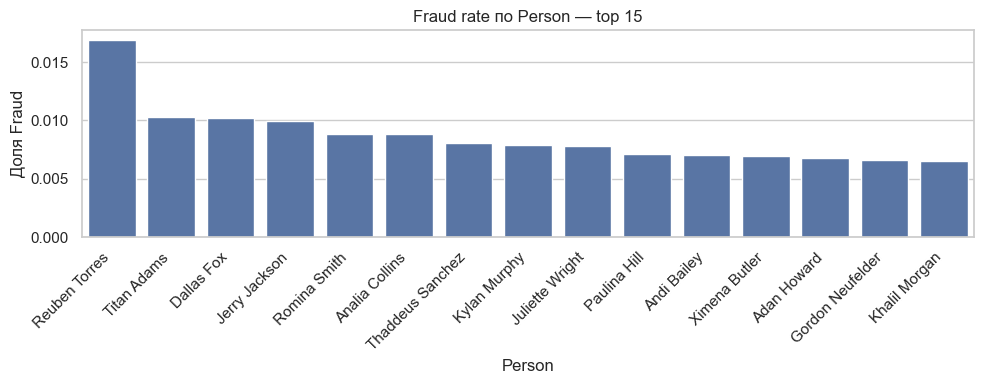

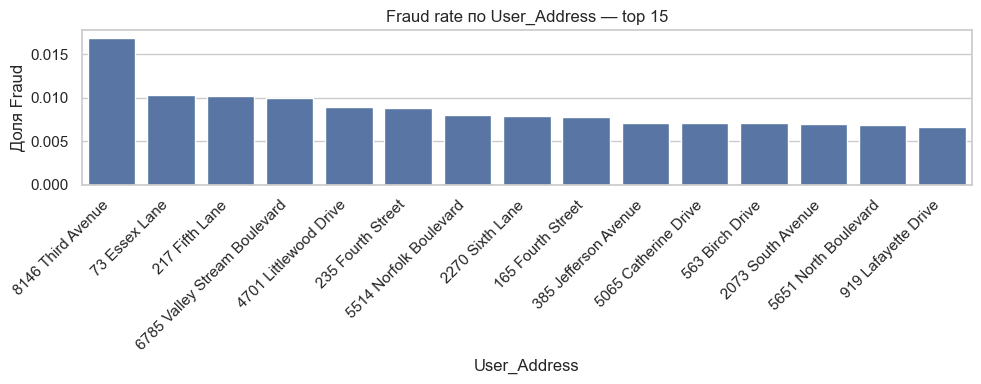

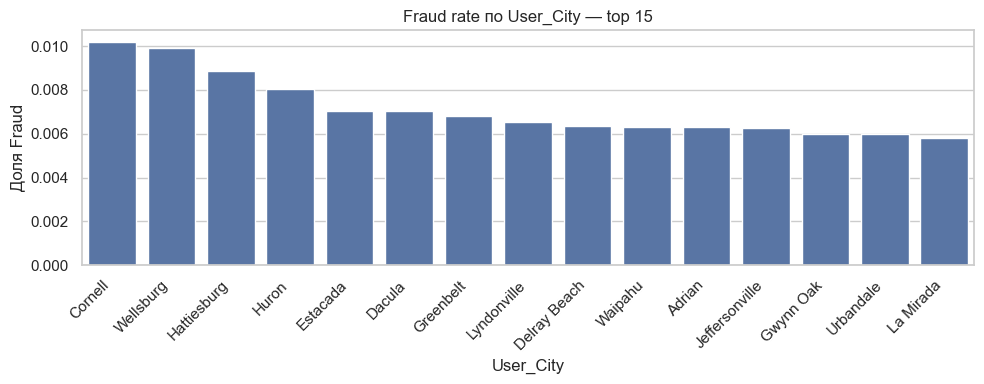

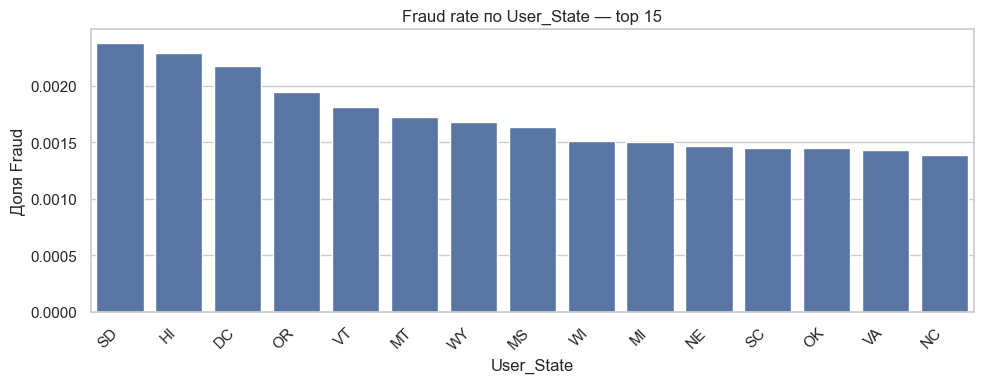

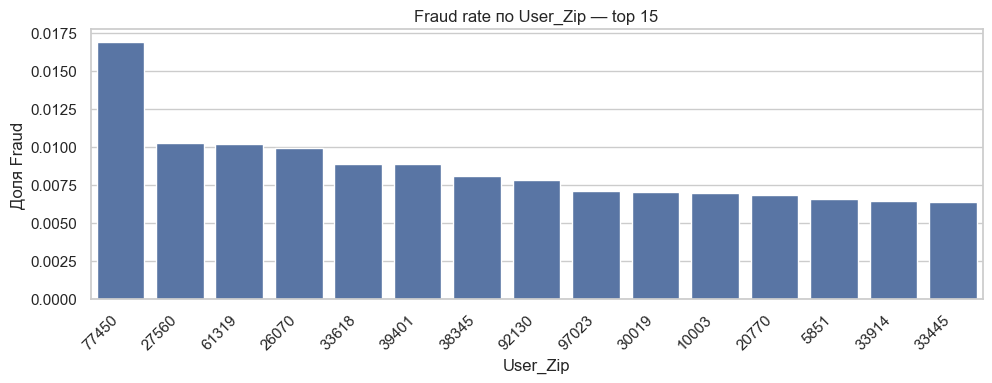

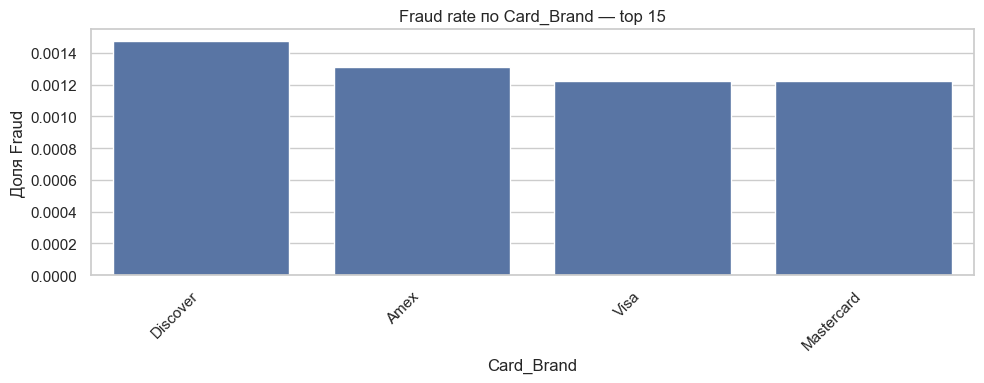

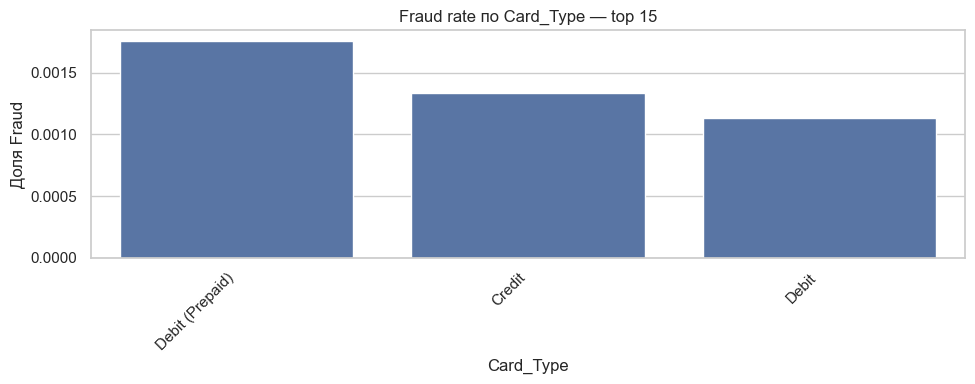

In [65]:
# Анализируем категориальные признаки по их Fraud rate. Для каждого категориального признака смотрим топ-15 значений с самым высоким уровнем мошенничества.

for col in cat_cols:
    fraud_rate = (
        data.groupby(col, dropna=False, observed=False)['Fraud']
          .mean()
          .sort_values(ascending=False)
          .head(15)
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(x=fraud_rate.index.astype(str), y=fraud_rate.values)
    plt.title(f'Fraud rate по {col} — top 15')
    plt.xlabel(col)
    plt.ylabel('Доля Fraud')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Видим несколько важных моментов.
1. Есть страны с огромным уровем мошенничества. Например, Тувалу. В реальности это вызвано тем, что многие мошшники регистрируют терминалы в этой стране из-за отсутствия сильной регуляции банковской сферы.
2. Технические ошибки связаны с мошенничеством. Больше всего если ошибки связаны с неверными данными карты - очевидно, когда человек пытается подобрать срок действия или код верификации. 
3. Снова видим, что в большинстве случаев имя и фамилия не влияют на риск мошенничества, т.е. идентификаторы бесполезны. Выбро одной комбинации или случайность или результат большей частоты этого имени.
4. Предоплаченные дебетовые карты больше подвергнуты риску. Судя по всему, это вызвано тем, что отношение к этим картам как к "одноразовым", пользователи часто платят ими на сомнительных сайтах что бы не раскрывать данные основных карт. 

## Проверяем возможные утечки

In [49]:
# Быстрый тест на возможную утечку данных - смотрим, есть ли признаки, для которых доля мошеннических транзакций в одном из значений признака 
# превышает 90%. Это может указывать на утечку данных, так-как модель может просто запомнить это значение и использовать его для предсказания.
for col in data.columns:
    if col != 'Fraud':
        rate = data.groupby(col, observed=False)['Fraud'].mean().max()
        if rate > 0.9:
            print(col, rate)

Timestamp 1.0
Amount 1.0
Merchant_ID 1.0
Merchant_City 1.0
Merchant_State 1.0
Merchant_Zip 1.0


In [50]:
# Результаты не однозначны. Мы выявили признаки с очень высокой кардинальностью, а не утечки. Проверим с дополнительным фильтом - 
# признак встречается не менее 50 раз. Это поможет отсеять признаки с высокой кардинальностью, которые встречаются очень редко и не являются утечкой.
for col in data.columns:
    if col != 'Fraud':
        grp = data.groupby(col, observed = False)['Fraud'].agg(['mean','count'])
        suspicious = grp[(grp['mean'] > 0.9) & (grp['count'] > 50)]
        
        if not suspicious.empty:
            print(col)
            print(suspicious.head())

Merchant_ID
                mean  count
Merchant_ID                
2156        0.903614     83
2297        0.986667     75
11013       1.000000    148
20497       0.923077     65
41507       0.983607     61
Merchant_City
                  mean  count
Merchant_City                
Algiers       0.962559    641
Funafuti      1.000000     59
Merchant_State
                   mean  count
Merchant_State                
Algeria        0.962559    641
Tuvalu         1.000000     59


In [51]:
# В данных есть скомпрометрированные мерчанты - для них доля мошеннических транзакций очень высокая. Посмотрим на них подробнее.
# Аналогично есть города и страны с очень высоким риском мошенничества. Например, островное микро-государство Тувалу.
# Это не утечка, но очень сильный признак. Нужно будет следить, что бы модель не переобучалась на этих признаках.
# Посмотрим на этих мерчантов детальнее

for col in ['Merchant_ID', 'Merchant_City', 'Merchant_State']:
    grp = (
        data.groupby(col, observed=False)['Fraud']
        .agg(['mean', 'count'])
        .sort_values(['mean', 'count'], ascending=[False, False])
    )
    print(f'\n===== {col} =====')
    display(grp[(grp['count'] >= 30)].head(20))


===== Merchant_ID =====


,mean,count
Merchant_ID,,
11013,1.000000,148
71380,1.000000,55
47155,1.000000,53
19463,1.000000,36
54978,1.000000,34
2297,0.986667,75
41507,0.983607,61
53492,0.976744,129
84960,0.962963,81



===== Merchant_City =====


,mean,count
Merchant_City,,
Funafuti,1.000000,59
Algiers,0.962559,641
Port au Prince,0.843891,442
Suva,0.800000,40
Abuja,0.632743,226
Istanbul,0.570455,440
Rome,0.354972,12863
Strasburg,0.175027,1834
Bucyrus,0.168421,285



===== Merchant_State =====


,mean,count
Merchant_State,,
Tuvalu,1.000000,59
Algeria,0.962559,641
Haiti,0.843891,442
Fiji,0.800000,40
Nigeria,0.632743,226
Turkey,0.570455,440
Italy,0.562469,8116
Japan,0.013360,3518
ONLINE,0.006456,2703530


In [52]:
# Посмотрим на характеристики данных
merchant_stats = (
    data.groupby('Merchant_ID')
    .agg(
        transactions=('Fraud','count'),
        fraud_rate=('Fraud','mean')
    )
)

merchant_stats.describe()

,transactions,fraud_rate
count,100342.000000,100342.000000
mean,230.633404,0.010041
std,7778.200312,0.091030
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,19.000000,0.000000
max,1129061.000000,1.000000


In [53]:
# Ещё раз посмотрим на распределение данных по мерчантам. Есть мерчанты с огромным числом транзакций.
# Скорее всего это супер крупные ритейлеры, которые обрабатывают огромное количество транзакций.
# Обычно уровень мошенничества в них минимальный
data['Merchant_ID'].value_counts().describe()

count    100342.000000
mean        230.633404
std        7778.200312
min           1.000000
25%           1.000000
50%           4.000000
75%          19.000000
max     1129061.000000
Name: count, dtype: float64

In [54]:
merchant_stats = (
    data.groupby('Merchant_ID')['Fraud']
    .agg(['count','mean'])
)

merchant_stats.sort_values('count', ascending=False).head(10)

,count,mean
Merchant_ID,,
27092,1129061,0.001423
61195,814504,0.000169
59935,797766,0.000139
39021,720604,0.000000
14528,573485,0.000017
60569,562151,0.002821
50783,541788,0.000041
22204,536260,0.000261
43293,486818,0.000199


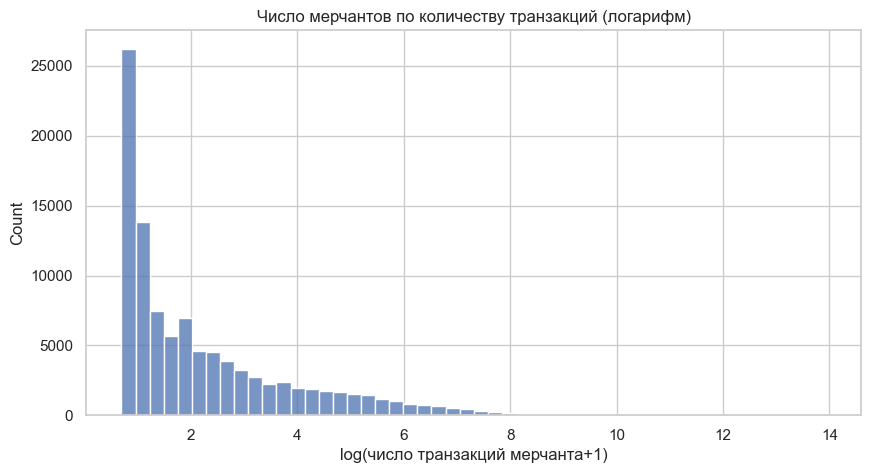

In [55]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(merchant_stats['count']), bins=50)
plt.title("Число мерчантов по количеству транзакций (логарифм)")
plt.xlabel("log(число транзакций мерчанта+1)")
plt.show()

Так и есть - но это не утечка, это - сильный признак. Чем больше у мерчанта транзакций - тем ниже риски. Нужно будет создать признак числа транзакций у мерчанта и использовать его вместо ID мерчанта. 

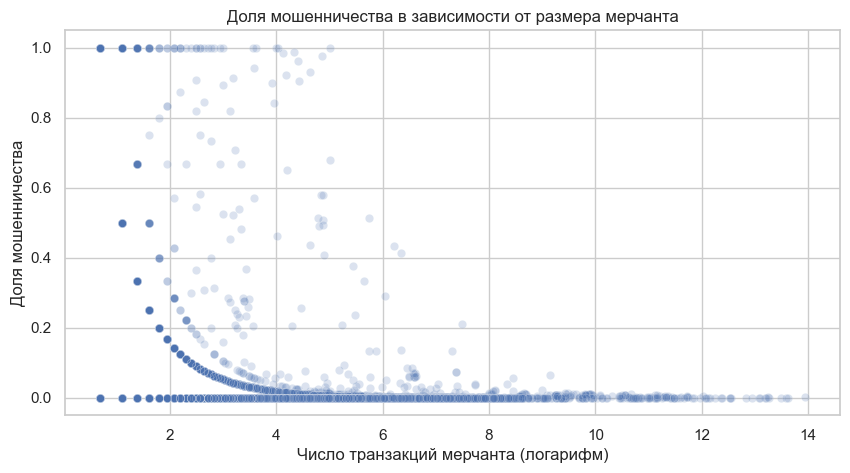

In [56]:
merchant_stats = (
    data.groupby('Merchant_ID')['Fraud']
    .agg(['count','mean'])
)

plt.figure(figsize=(10,5))
sns.scatterplot(
    x=np.log1p(merchant_stats['count']),
    y=merchant_stats['mean'],
    alpha=0.2
)

plt.xlabel("Число транзакций мерчанта (логарифм)")
plt.ylabel("Доля мошенничества")
plt.title("Доля мошенничества в зависимости от размера мерчанта")
plt.show()

Мы убедились, что:
1. Нельзя будет использовать Merchant_ID как признак - модель переобучится и не сможет находить мошенничество на незнакомых мерчантах.
2. Вместо этого признака нужно создать признак величины мерчанта и считать его через коммулятивную сумму (т.е. когда мерчант встретится впервые у него будет 0)
3. Возможно создать признак - % мошенничества на момент транзакции. Но тут надо быть очень осторожным чтобы не создать утечку. Посмотрим уже при создании признаков.

## Блоки разного

In [57]:
# Проверим статистически значимую взаимосвязь между числовыми признаками и мошенничеством
from scipy.stats import mannwhitneyu

num_cols = data.select_dtypes(include=['int','float']).columns
num_cols = [c for c in num_cols if c!='Fraud']

results = []

for col in num_cols:
    
    fraud = data[data['Fraud']==1][col]
    nonfraud = data[data['Fraud']==0][col]
    
    stat, p = mannwhitneyu(fraud, nonfraud)
    
    results.append({
        'feature': col,
        'p_value': p
    })

mw_results = pd.DataFrame(results).sort_values('p_value')

display(mw_results)

,feature,p_value
0,Amount,0.000000
2,Merchant_USA,0.000000
3,MCC,0.000000
1,Merchant_ID,0.000000
10,Credit_Limit,0.000000
7,Yearly_Income,0.000000
8,Total_Debt,0.000000
6,Per_Capita_Income_Zipcode,0.000000
5,User_Longitude,0.000000
4,User_Latitude,0.006134
